In [4045]:
# library imports
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import os
import sklearn
from fifacodes import Members

In [3926]:
# load kaggle data
kaggle = pd.read_csv('data/train.csv')

In [3927]:
print(kaggle.shape)

kaggle.columns

(192, 24)


Index(['version', 'team', 'continent', 'is_host', 'goals_scored_last_4y',
       'goals_received_last_4y', 'wins_last_4y', 'losses_last_4y',
       'draws_last_4y', 'world_cup_titles_before',
       'squad_total_market_value_eur', 'fifa_rank_pre_tournament',
       'fifa_points_pre_tournament', 'squad_avg_age',
       'world_cup_participations_before', 'groups_passed_before',
       'round16_before', 'quarterfinals_before', 'semifinals_before',
       'finals_before', 'winner', 'finalist', 'semi_finalist',
       'quarter_finalist'],
      dtype='object')

In [3928]:
kaggle.iloc[:,0:12].describe()

,version,is_host,goals_scored_last_4y,goals_received_last_4y,wins_last_4y,losses_last_4y,draws_last_4y,world_cup_titles_before,squad_total_market_value_eur,fifa_rank_pre_tournament
count,192.00000,192.000000,192.000000,192.000000,192.000000,192.000000,192.000000,192.000000,1.600000e+02,192.000000
mean,2012.00000,0.036458,84.583333,44.572917,26.046875,11.052083,11.802083,0.427083,3.433053e+08,23.541667
std,6.84916,0.187918,23.731776,13.608009,6.912534,4.745612,3.496055,1.085312,3.489032e+08,18.214497
min,2002.00000,0.000000,28.000000,19.000000,8.000000,2.000000,4.000000,0.000000,6.270000e+06,1.000000
25%,2006.00000,0.000000,66.000000,35.000000,21.000000,8.000000,10.000000,0.000000,9.385750e+07,9.000000
50%,2012.00000,0.000000,83.500000,42.500000,25.000000,10.500000,12.000000,0.000000,2.179400e+08,20.000000
75%,2018.00000,0.000000,102.000000,53.250000,31.000000,14.000000,14.000000,0.000000,4.129750e+08,34.000000
max,2022.00000,1.000000,156.000000,95.000000,48.000000,30.000000,23.000000,5.000000,1.620000e+09,105.000000


In [3929]:
kaggle.iloc[:,12:].describe()

,fifa_points_pre_tournament,squad_avg_age,world_cup_participations_before,groups_passed_before,round16_before,quarterfinals_before,semifinals_before,finals_before,winner,finalist,semi_finalist,quarter_finalist
count,192.000000,192.000000,192.000000,192.000000,192.000000,192.000000,192.000000,192.000000,192.000000,192.000000,192.000000,192.000000
mean,954.165469,27.249635,5.625000,3.572917,2.244792,2.223958,1.348958,0.697917,0.031250,0.062500,0.125000,0.250000
std,367.544609,1.092351,5.548926,4.584848,2.701071,3.525056,2.618520,1.731263,0.174448,0.242694,0.331584,0.434145
min,285.000000,23.920000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,670.500000,26.560000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,824.000000,27.225000,4.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,1182.500000,28.000000,10.000000,6.250000,4.000000,3.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.250000
max,1841.300000,29.780000,21.000000,19.000000,11.000000,16.000000,13.000000,8.000000,1.000000,1.000000,1.000000,1.000000


In [3930]:
kaggle.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 192 entries, 0 to 191
Data columns (total 24 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   version                          192 non-null    int64  
 1   team                             192 non-null    object 
 2   continent                        192 non-null    object 
 3   is_host                          192 non-null    int64  
 4   goals_scored_last_4y             192 non-null    int64  
 5   goals_received_last_4y           192 non-null    int64  
 6   wins_last_4y                     192 non-null    int64  
 7   losses_last_4y                   192 non-null    int64  
 8   draws_last_4y                    192 non-null    int64  
 9   world_cup_titles_before          192 non-null    int64  
 10  squad_total_market_value_eur     160 non-null    float64
 11  fifa_rank_pre_tournament         192 non-null    int64  
 12  fifa_points_pre_tourna

In [3931]:
kaggle_clean = kaggle[[
    'version',
    'team',
    'is_host',
    'goals_scored_last_4y',
    'goals_received_last_4y',
    'wins_last_4y',
    'losses_last_4y',
    'draws_last_4y',
    'world_cup_titles_before',
    'fifa_rank_pre_tournament',
    'fifa_points_pre_tournament',
    'squad_avg_age',
    'world_cup_participations_before',
    'groups_passed_before',
    'round16_before',
    'quarterfinals_before',
    'semifinals_before',
    'finals_before'
]].copy()

kaggle_clean['tournament_id'] = kaggle_clean['version'].map({2002:'WC-2002',2006:'WC-2006',2010:'WC-2010',
                                                             2014:'WC-2014',2018:'WC-2018',2022:'WC-2022'})

members = Members()
fifa_dict = {member.name: member.code for name, member in members.items()}
# manually fix country codes for teams not found in fifacodes
fifa_dict['China PR'] = 'CHN'
fifa_dict['Serbia and Montenegro'] = 'SCG'
kaggle_clean['team_code'] = kaggle_clean['team'].map(fifa_dict)

kaggle_clean = kaggle_clean.drop(columns = ['version'])

In [3932]:
# manually fill kaggle dataset for teams missing
# AGO (Angola) 2006, TGO (Togo) 2006, TTO (Trinidad) 2006, HND (Honduras) 2010/2014
missing_teams = pd.DataFrame([
    # Angola 2006 data
    {'tournament_id': 'WC-2006', 'team_code': 'AGO', 'is_host': 0, 
     'fifa_rank_pre_tournament': 57, 'fifa_points_pre_tournament': 581,
     # 2005, 2004, 2003, 2002
     'goals_scored_last_4y': 11+23+9+4,
     'goals_received_last_4y': 12+14+7+10,
     'wins_last_4y': 4+8+2+0,
     'losses_last_4y': 3+3+2+3,
     'draws_last_4y': 2+4+9+2,
     'world_cup_titles_before': 0},

     # Togo 2006 data
    {'tournament_id': 'WC-2006', 'team_code': 'TGO', 'is_host': 0, 
     'fifa_rank_pre_tournament': 61, 'fifa_points_pre_tournament': 569,
     # 2005, 2004, 2003, 2002
     'goals_scored_last_4y': 12+6+9+7,
     'goals_received_last_4y': 4+4+7+9,
     'wins_last_4y': 5+2+3+3,
     'losses_last_4y': 0+2+2+3,
     'draws_last_4y': 2+3+0+4,
     'world_cup_titles_before': 0},

     # Trinidad 2006 data
    {'tournament_id': 'WC-2006', 'team_code': 'TTO', 'is_host': 0, 
     'fifa_rank_pre_tournament': 47, 'fifa_points_pre_tournament': 604,
     # 2005, 2004, 2003, 2002
     'goals_scored_last_4y': 52+20+14+4,
     'goals_received_last_4y': 37+19+22+13,
     'wins_last_4y': 18+7+4+1,
     'losses_last_4y': 11+5+10+5,
     'draws_last_4y': 2+2+3+4,
     'world_cup_titles_before': 0},

     # Honduras 2010 data
    {'tournament_id': 'WC-2010', 'team_code': 'HND', 'is_host': 0, 
     'fifa_rank_pre_tournament': 38, 'fifa_points_pre_tournament': 734,
     # 2009, 2008, 2007, 2006
     'goals_scored_last_4y': 25+20+38+15,
     'goals_received_last_4y': 14+8+21+13,
     'wins_last_4y': 10+8+9+5,
     'losses_last_4y': 5+1+5+3,
     'draws_last_4y': 1+4+3+1,
     'world_cup_titles_before': 0},

     # Honduras 2014 data
    {'tournament_id': 'WC-2014', 'team_code': 'HND', 'is_host': 0, 
     'fifa_rank_pre_tournament': 33, 'fifa_points_pre_tournament': 731,
     # 2013, 2012, 2011, 2010
     'goals_scored_last_4y': 26+7+27+27,
     'goals_received_last_4y': 18+14+26+24,
     'wins_last_4y': 9+3+6+9,
     'losses_last_4y': 7+7+6+10,
     'draws_last_4y': 5+3+7+3,
     'world_cup_titles_before': 0},
])

kaggle_clean = pd.concat([kaggle_clean, missing_teams], ignore_index=True)

In [3933]:
kaggle_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 197 entries, 0 to 196
Data columns (total 19 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   team                             192 non-null    object 
 1   is_host                          197 non-null    int64  
 2   goals_scored_last_4y             197 non-null    int64  
 3   goals_received_last_4y           197 non-null    int64  
 4   wins_last_4y                     197 non-null    int64  
 5   losses_last_4y                   197 non-null    int64  
 6   draws_last_4y                    197 non-null    int64  
 7   world_cup_titles_before          197 non-null    int64  
 8   fifa_rank_pre_tournament         197 non-null    int64  
 9   fifa_points_pre_tournament       197 non-null    float64
 10  squad_avg_age                    192 non-null    float64
 11  world_cup_participations_before  192 non-null    float64
 12  groups_passed_before  

In [3934]:
folder = 'data/data-csv/'

for file in os.listdir(folder):
    if file.endswith('.csv'):
        df = pd.read_csv(os.path.join(folder, file))
        print(f"\n{file}")
        print(df.shape)
        print(df.columns.tolist())


groups.csv
(159, 7)
['key_id', 'tournament_id', 'tournament_name', 'stage_number', 'stage_name', 'group_name', 'count_teams']

managers.csv
(475, 7)
['key_id', 'manager_id', 'family_name', 'given_name', 'female', 'country_name', 'manager_wikipedia_link']

qualified_teams.csv
(625, 8)
['key_id', 'tournament_id', 'tournament_name', 'team_id', 'team_name', 'team_code', 'count_matches', 'performance']

teams.csv
(88, 14)
['key_id', 'team_id', 'team_name', 'team_code', 'mens_team', 'womens_team', 'federation_name', 'region_name', 'confederation_id', 'confederation_name', 'confederation_code', 'mens_team_wikipedia_link', 'womens_team_wikipedia_link', 'federation_wikipedia_link']

player_appearances.csv
(27432, 21)
['key_id', 'tournament_id', 'tournament_name', 'match_id', 'match_name', 'match_date', 'stage_name', 'group_name', 'team_id', 'team_name', 'team_code', 'home_team', 'away_team', 'player_id', 'family_name', 'given_name', 'shirt_number', 'position_name', 'position_code', 'starter', 

In [3935]:
# load jfjelstul tables that are most useful
matches = pd.read_csv('data/data-csv/matches.csv')
squads = pd.read_csv('data/data-csv/squads.csv')
players = pd.read_csv('data/data-csv/players.csv')
player_appearances = pd.read_csv('data/data-csv/player_appearances.csv')
goals = pd.read_csv('data/data-csv/goals.csv')

In [3936]:
matches.columns

Index(['key_id', 'tournament_id', 'tournament_name', 'match_id', 'match_name',
       'stage_name', 'group_name', 'group_stage', 'knockout_stage', 'replayed',
       'replay', 'match_date', 'match_time', 'stadium_id', 'stadium_name',
       'city_name', 'country_name', 'home_team_id', 'home_team_name',
       'home_team_code', 'away_team_id', 'away_team_name', 'away_team_code',
       'score', 'home_team_score', 'away_team_score', 'home_team_score_margin',
       'away_team_score_margin', 'extra_time', 'penalty_shootout',
       'score_penalties', 'home_team_score_penalties',
       'away_team_score_penalties', 'result', 'home_team_win', 'away_team_win',
       'draw'],
      dtype='object')

In [3937]:
# trim tables to 2002 onwards and most useful features
recent_cups = [f"WC-{4 * x + 2002}" for x in range(6)]

matches_clean = (
    matches[matches['tournament_id'].isin(recent_cups)][[
        # identifiers
        'tournament_id',
        'match_id',
        'stage_name',
        'group_name',
        'group_stage',
        'knockout_stage',
        'match_date',

        # team info
        'home_team_id',
        'home_team_code',
        'away_team_id',
        'away_team_code',

        # scores and results
        'home_team_score',
        'away_team_score',
        'home_team_win',
        'away_team_win',
        'draw',
        'penalty_shootout'
]]
        .replace({'not applicable':pd.NA})
        .copy()
)

In [3938]:
matches_clean.tail()

,tournament_id,match_id,stage_name,group_name,group_stage,knockout_stage,match_date,home_team_id,home_team_code,away_team_id,away_team_code,home_team_score,away_team_score,home_team_win,away_team_win,draw,penalty_shootout
1243,WC-2022,M-2022-60,quarter-finals,<NA>,0,1,2022-12-10,T-28,ENG,T-30,FRA,1,2,0,1,0,0
1244,WC-2022,M-2022-61,semi-finals,<NA>,0,1,2022-12-13,T-03,ARG,T-18,HRV,3,0,1,0,0,0
1245,WC-2022,M-2022-62,semi-finals,<NA>,0,1,2022-12-14,T-30,FRA,T-47,MAR,2,0,1,0,0,0
1246,WC-2022,M-2022-63,third-place match,<NA>,0,1,2022-12-17,T-18,HRV,T-47,MAR,2,1,1,0,0,0
1247,WC-2022,M-2022-64,final,<NA>,0,1,2022-12-18,T-03,ARG,T-30,FRA,3,3,1,0,0,1


In [3939]:
squads.shape

(13843, 12)

In [3940]:
squads.tail(10)

,key_id,tournament_id,tournament_name,team_id,team_name,team_code,player_id,family_name,given_name,shirt_number,position_name,position_code
13833,13834,WC-2022,2022 FIFA Men's World Cup,T-85,Wales,WAL,P-34567,Lockyer,Tom,17,defender,DF
13834,13835,WC-2022,2022 FIFA Men's World Cup,T-85,Wales,WAL,P-56664,Williams,Jonny,18,midfielder,MF
13835,13836,WC-2022,2022 FIFA Men's World Cup,T-85,Wales,WAL,P-37173,Harris,Mark,19,forward,FW
13836,13837,WC-2022,2022 FIFA Men's World Cup,T-85,Wales,WAL,P-74707,James,Daniel,20,forward,FW
13837,13838,WC-2022,2022 FIFA Men's World Cup,T-85,Wales,WAL,P-92482,Davies,Adam,21,goal keeper,GK
13838,13839,WC-2022,2022 FIFA Men's World Cup,T-85,Wales,WAL,P-20564,Thomas,Sorba,22,midfielder,MF
13839,13840,WC-2022,2022 FIFA Men's World Cup,T-85,Wales,WAL,P-24982,Levitt,Dylan,23,midfielder,MF
13840,13841,WC-2022,2022 FIFA Men's World Cup,T-85,Wales,WAL,P-02030,Cabango,Ben,24,defender,DF
13841,13842,WC-2022,2022 FIFA Men's World Cup,T-85,Wales,WAL,P-07137,Colwill,Rubin,25,midfielder,MF
13842,13843,WC-2022,2022 FIFA Men's World Cup,T-85,Wales,WAL,P-84269,Smith,Matthew,26,midfielder,MF


In [3941]:
squads.columns

Index(['key_id', 'tournament_id', 'tournament_name', 'team_id', 'team_name',
       'team_code', 'player_id', 'family_name', 'given_name', 'shirt_number',
       'position_name', 'position_code'],
      dtype='object')

In [3942]:
squads_clean = squads[squads['tournament_id'].isin(recent_cups)][[
    'tournament_id',
    'team_code',
    'player_id',
    'family_name',
    'given_name',
    'position_code'
]].copy()

In [3943]:
squads_clean.head()

,tournament_id,team_code,player_id,family_name,given_name,position_code
7238,WC-2002,ARG,P-56385,Burgos,Germán,GK
7239,WC-2002,ARG,P-83403,Ayala,Roberto,DF
7240,WC-2002,ARG,P-60914,Sorín,Juan Pablo,DF
7241,WC-2002,ARG,P-31684,Pochettino,Mauricio,DF
7242,WC-2002,ARG,P-88203,Almeyda,Matías,MF


In [3944]:
players.shape

(10401, 13)

In [3945]:
players.head()

,key_id,player_id,family_name,given_name,birth_date,female,goal_keeper,defender,midfielder,forward,count_tournaments,list_tournaments,player_wikipedia_link
0,1,P-35894,A'Court,Alan,1934-09-30,0,0,0,0,1,1,1958,https://en.wikipedia.org/wiki/Alan_A%27Court
1,2,P-29915,Aarønes,Ann Kristin,1973-01-19,1,0,0,1,1,2,"1995, 1999",https://en.wikipedia.org/wiki/Ann_Kristin_Aar%...
2,3,P-03484,Aaronson,Brenden,2000-10-22,0,0,0,0,1,1,2022,https://en.wikipedia.org/wiki/Brenden_Aaronson
3,4,P-04189,Abadzhiev,Stefan,1934-07-03,0,0,0,0,1,1,1966,https://en.wikipedia.org/wiki/Stefan_Abadzhiev
4,5,P-03523,Abalo,Jean-Paul,1975-06-26,0,0,1,0,0,1,2006,https://en.wikipedia.org/wiki/Jean-Paul_Abalo


In [3946]:
players.columns

Index(['key_id', 'player_id', 'family_name', 'given_name', 'birth_date',
       'female', 'goal_keeper', 'defender', 'midfielder', 'forward',
       'count_tournaments', 'list_tournaments', 'player_wikipedia_link'],
      dtype='object')

In [3947]:
players_clean = players[players['female'] == 0][[
    'player_id',
    'birth_date',
]].copy()

In [3948]:
players_clean.head()

,player_id,birth_date
0,P-35894,1934-09-30
2,P-03484,2000-10-22
3,P-04189,1934-07-03
4,P-03523,1975-06-26
6,P-35138,1978-08-03


In [3949]:
player_appearances.columns

Index(['key_id', 'tournament_id', 'tournament_name', 'match_id', 'match_name',
       'match_date', 'stage_name', 'group_name', 'team_id', 'team_name',
       'team_code', 'home_team', 'away_team', 'player_id', 'family_name',
       'given_name', 'shirt_number', 'position_name', 'position_code',
       'starter', 'substitute'],
      dtype='object')

In [3950]:
player_appearances_clean = player_appearances[player_appearances['tournament_id'].isin(recent_cups)][[
    'tournament_id',
    'match_id',
    'team_code',
    'player_id',
    'starter',
    'substitute'
]].copy()

In [3951]:
player_appearances_clean.head(20)

,tournament_id,match_id,team_code,player_id,starter,substitute
11110,WC-2002,M-2002-01,FRA,P-56735,1,0
11111,WC-2002,M-2002-01,FRA,P-96540,1,0
11112,WC-2002,M-2002-01,FRA,P-80680,1,0
11113,WC-2002,M-2002-01,FRA,P-79380,1,0
11114,WC-2002,M-2002-01,FRA,P-00916,1,0
11115,WC-2002,M-2002-01,FRA,P-51395,1,0
11116,WC-2002,M-2002-01,FRA,P-56947,1,0
11117,WC-2002,M-2002-01,FRA,P-55991,1,0
11118,WC-2002,M-2002-01,FRA,P-40400,1,0
11119,WC-2002,M-2002-01,FRA,P-19907,1,0


In [3952]:
goals.columns

Index(['key_id', 'goal_id', 'tournament_id', 'tournament_name', 'match_id',
       'match_name', 'match_date', 'stage_name', 'group_name', 'team_id',
       'team_name', 'team_code', 'home_team', 'away_team', 'player_id',
       'family_name', 'given_name', 'shirt_number', 'player_team_id',
       'player_team_name', 'player_team_code', 'minute_label',
       'minute_regulation', 'minute_stoppage', 'match_period', 'own_goal',
       'penalty'],
      dtype='object')

In [3953]:
goals_clean = goals[goals['tournament_id'].isin(recent_cups)][[
    'goal_id',
    'tournament_id',
    'match_id',
    'player_id',
    'player_team_code',
    'minute_regulation',
    'minute_stoppage',
    'match_period',
    'own_goal',
    'penalty'
]].copy()

In [3954]:
goals_clean.head()

,goal_id,tournament_id,match_id,player_id,player_team_code,minute_regulation,minute_stoppage,match_period,own_goal,penalty
2076,G-2077,WC-2002,M-2002-01,P-82212,SEN,30,0,first half,0,0
2077,G-2078,WC-2002,M-2002-02,P-18804,CMR,39,0,first half,0,0
2078,G-2079,WC-2002,M-2002-02,P-00105,IRL,52,0,second half,0,0
2079,G-2080,WC-2002,M-2002-03,P-50534,DNK,45,0,first half,0,0
2080,G-2081,WC-2002,M-2002-03,P-49428,URY,47,0,second half,0,0


In [3955]:
# fix discrepancies between Kaggle and FIFA codes for countries
code_map = {
    'DEU': 'GER',  # Germany
    'CHE': 'SUI',  # Switzerland
    'HRV': 'CRO',  # Croatia
    'NLD': 'NED',  # Netherlands
    'PRT': 'POR',  # Portugal
    'DZA': 'ALG',  # Algeria
    'CHL': 'CHI',  # Chile
    'DNK': 'DEN',  # Denmark
    'GRC': 'GRE',  # Greece
    'PRY': 'PAR',  # Paraguay
    'SAU': 'KSA',  # Saudi Arabia
    'URY': 'URU',  # Uruguay
    'ZAF': 'RSA',  # South Africa
    'CRI': 'CRC'   # Costa Rica
}

for df in [kaggle_clean, matches_clean, squads_clean, players_clean, player_appearances_clean, goals_clean]:
    for col in ['home_team_code', 'away_team_code', 'team_code']:
        if col in df.columns:
            df[col] = df[col].replace(code_map)

In [3956]:
goals_agg = (goals_clean
    .groupby(['tournament_id', 'match_id', 'player_team_code'])
    .agg(
        goals_scored = ('goal_id', 'count'),
        own_goals = ('own_goal', 'sum'),
        penalties = ('penalty', 'sum')
    )
    .reset_index()
)

goals_agg.head()

,tournament_id,match_id,player_team_code,goals_scored,own_goals,penalties
0,WC-2002,M-2002-01,SEN,1,0,0
1,WC-2002,M-2002-02,CMR,1,0,0
2,WC-2002,M-2002-02,IRL,1,0,0
3,WC-2002,M-2002-03,DNK,2,0,0
4,WC-2002,M-2002-03,URY,1,0,0


In [3957]:
match_table = (matches_clean
    .merge(
        goals_agg.rename(columns = {'player_team_code':'home_team_code', 'goals_scored': 'home_goals_scored',
                                  'own_goals':'home_own_goals', 'penalties': 'home_penalties'}),
        on = ['tournament_id','match_id','home_team_code'], how = 'left'
    )
    .merge(
        goals_agg.rename(columns = {'player_team_code':'away_team_code', 'goals_scored':'away_goals_scored',
                                  'own_goals':'away_own_goals', 'penalties':'away_penalties'}),
        on = ['tournament_id','match_id','away_team_code'], how = 'left'
    )
    .fillna(0)
)

match_table['group_name'] = match_table['group_name'].str[6:]

In [3958]:
match_table.head()

,tournament_id,match_id,stage_name,group_name,group_stage,knockout_stage,match_date,home_team_id,home_team_code,away_team_id,away_team_code,home_team_score,away_team_score,home_team_win,away_team_win,draw,penalty_shootout,home_goals_scored,home_own_goals,home_penalties,away_goals_scored,away_own_goals,away_penalties
0,WC-2002,M-2002-01,group stage,A,1,0,2002-05-31,T-30,FRA,T-65,SEN,0,1,0,1,0,0,0.0,0.0,0.0,1.0,0.0,0.0
1,WC-2002,M-2002-02,group stage,E,1,0,2002-06-01,T-60,IRL,T-11,CMR,1,1,0,0,1,0,1.0,0.0,0.0,1.0,0.0,0.0
2,WC-2002,M-2002-03,group stage,A,1,0,2002-06-01,T-84,URU,T-22,DEN,1,2,0,1,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,WC-2002,M-2002-04,group stage,E,1,0,2002-06-01,T-31,GER,T-63,KSA,8,0,1,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
4,WC-2002,M-2002-05,group stage,F,1,0,2002-06-02,T-03,ARG,T-50,NGA,1,0,1,0,0,0,1.0,0.0,0.0,0.0,0.0,0.0


In [3959]:
kaggle_clean.head()

,team,is_host,goals_scored_last_4y,goals_received_last_4y,wins_last_4y,losses_last_4y,draws_last_4y,world_cup_titles_before,fifa_rank_pre_tournament,fifa_points_pre_tournament,squad_avg_age,world_cup_participations_before,groups_passed_before,round16_before,quarterfinals_before,semifinals_before,finals_before,tournament_id,team_code
0,Angola,0,61,49,19,13,14,0,57,581.0,29.2,0.0,0.0,0.0,0.0,0.0,0.0,WC-2006,ANG
1,Argentina,0,97,55,31,10,10,2,9,746.0,27.8,13.0,10.0,5.0,6.0,4.0,4.0,WC-2006,ARG
2,Australia,0,101,34,23,8,5,0,42,612.0,27.1,1.0,0.0,0.0,0.0,0.0,0.0,WC-2006,AUS
3,Brazil,0,117,47,30,9,17,5,1,827.0,27.1,17.0,15.0,7.0,11.0,9.0,6.0,WC-2006,BRA
4,Costa Rica,0,89,84,26,25,11,0,26,683.0,24.7,2.0,1.0,1.0,0.0,0.0,0.0,WC-2006,CRC


In [3960]:
match_table = (match_table
    .merge(
        kaggle_clean[['tournament_id', 'team_code', 'is_host', 'goals_scored_last_4y', 'goals_received_last_4y',
                      'wins_last_4y', 'losses_last_4y', 'draws_last_4y', 'fifa_rank_pre_tournament',
                      'fifa_points_pre_tournament','world_cup_participations_before']]
        .rename(columns = {
            'team_code': 'home_team_code',
            'is_host': 'home_is_host',
            'goals_scored_last_4y': 'home_goals_scored_last_4y',
            'goals_received_last_4y': 'home_goals_received_last_4y',
            'wins_last_4y': 'home_wins_last_4y',
            'losses_last_4y': 'home_losses_last_4y',
            'draws_last_4y': 'home_draws_last_4y',
            'fifa_rank_pre_tournament': 'home_fifa_rank_pre_tournament',
            'fifa_points_pre_tournament': 'home_fifa_points_pre_tournament',
            'world_cup_participations_before':'home_world_cups_before'
        }),
        on = ['tournament_id', 'home_team_code'], how = 'left'
    )
    .merge(
        kaggle_clean[['tournament_id', 'team_code', 'is_host', 'goals_scored_last_4y', 'goals_received_last_4y',
                      'wins_last_4y', 'losses_last_4y', 'draws_last_4y', 'fifa_rank_pre_tournament',
                      'fifa_points_pre_tournament','world_cup_participations_before']]
        .rename(columns = {
            'team_code': 'away_team_code',
            'is_host': 'away_is_host',
            'goals_scored_last_4y': 'away_goals_scored_last_4y',
            'goals_received_last_4y': 'away_goals_received_last_4y',
            'wins_last_4y': 'away_wins_last_4y',
            'losses_last_4y': 'away_losses_last_4y',
            'draws_last_4y': 'away_draws_last_4y',
            'fifa_rank_pre_tournament': 'away_fifa_rank_pre_tournament',
            'fifa_points_pre_tournament': 'away_fifa_points_pre_tournament',
            'world_cup_participations_before':'away_world_cups_before'
        }),
        on = ['tournament_id', 'away_team_code'], how = 'left'
    )
)

In [3961]:
confederations = pd.read_csv('data/team_confederation.csv')
confederations['team_code'] = confederations['country'].map(fifa_dict)
confederations.loc[confederations['country'] == 'United Kingdom','team_code'] = 'ENG'
confederations.loc[confederations['country'] == 'Ireland','team_code'] = 'IRL'
confederations.loc[confederations['country'] == 'Curacao','team_code'] = 'CUW'
confederations.loc[confederations['country'] == 'Congo DR','team_code'] = 'COD'
confederations.loc[confederations['country'] == 'Trinidad &Tobago','team_code'] = 'TRI'
confederations.loc[confederations['country'] == 'Bosnia-Herzegovina','team_code'] = 'BIH'
confederations = confederations [['team_code','confederation']].dropna(subset = 'team_code')

confed_strength = {
    'UEFA': 1.00,
    'CONMEBOL': 0.95,
    'CAF': 0.80,
    'CONCACAF': 0.75,
    'AFC': 0.75,
    'OFC': 0.60
}
confederations['confed_strength'] = confederations['confederation'].map(confed_strength)

match_table = (match_table
    .merge(confederations[['team_code','confed_strength']]
           .rename(columns = {
               'team_code':'home_team_code',
               'confed_strength':'home_confed_strength'}),
           on = 'home_team_code', how = 'left')
    .merge(confederations[['team_code','confed_strength']]
           .rename(columns = {
               'team_code':'away_team_code',
               'confed_strength':'away_confed_strength'}),
           on = 'away_team_code', how = 'left')
)

In [3962]:
for feature in [
    'home_goals_scored_last_4y',
    'home_wins_last_4y',
]:
    match_table[feature] = (
        match_table[feature] * match_table['home_confed_strength']
    )
for feature in [
    'away_goals_scored_last_4y',
    'away_wins_last_4y',
]:
    match_table[feature] = (
        match_table[feature] * match_table['away_confed_strength']
    )

In [3963]:
# drop columns that would create data leakage for training
match_table = match_table.drop(columns = ['stage_name','home_own_goals','home_penalties','away_own_goals',
                                          'away_penalties','penalty_shootout','home_confed_strength','away_confed_strength'])

# convert match date to year
match_table['match_date'] = pd.to_datetime(match_table['match_date'])
# calculate difference in fifa rank and points between teams
match_table['fifa_rank_diff'] = match_table['home_fifa_rank_pre_tournament'] - match_table['away_fifa_rank_pre_tournament']
match_table['fifa_pt_diff'] = match_table['home_fifa_points_pre_tournament'] - match_table['away_fifa_points_pre_tournament']

drop_before_training = ['tournament_id','match_id','home_team_id','home_team_code','away_team_id','away_team_code',
                        'match_date','home_team_win','draw','away_team_win','group_name','home_goals_scored',
                        'away_goals_scored','home_team_score','away_team_score']

In [3964]:
match_table.head()

,tournament_id,match_id,group_name,group_stage,knockout_stage,match_date,home_team_id,home_team_code,away_team_id,away_team_code,home_team_score,away_team_score,home_team_win,away_team_win,draw,home_goals_scored,away_goals_scored,home_is_host,home_goals_scored_last_4y,home_goals_received_last_4y,home_wins_last_4y,home_losses_last_4y,home_draws_last_4y,home_fifa_rank_pre_tournament,home_fifa_points_pre_tournament,home_world_cups_before,away_is_host,away_goals_scored_last_4y,away_goals_received_last_4y,away_wins_last_4y,away_losses_last_4y,away_draws_last_4y,away_fifa_rank_pre_tournament,away_fifa_points_pre_tournament,away_world_cups_before,fifa_rank_diff,fifa_pt_diff
0,WC-2002,M-2002-01,A,1,0,2002-05-31,T-30,FRA,T-65,SEN,0,1,0,1,0,0.0,1.0,0,101.0,39,33.00,6,10,1,802.0,10.0,0,63.2,46,20.8,12,21,42,599.0,0.0,-41,203.0
1,WC-2002,M-2002-02,E,1,0,2002-06-01,T-60,IRL,T-11,CMR,1,1,0,0,1,1.0,1.0,0,66.0,28,21.00,7,9,15,674.0,2.0,0,52.0,25,18.4,5,13,17,672.0,4.0,-2,2.0
2,WC-2002,M-2002-03,A,1,0,2002-06-01,T-84,URU,T-22,DEN,1,2,0,1,0,0.0,0.0,0,53.2,50,17.10,15,12,24,652.0,9.0,0,62.0,38,20.0,10,11,20,657.0,2.0,4,-5.0
3,WC-2002,M-2002-04,E,1,0,2002-06-01,T-31,GER,T-63,KSA,8,0,1,0,0,0.0,0.0,0,100.0,58,24.00,13,10,11,695.0,14.0,0,117.0,73,36.0,17,13,34,627.0,2.0,-23,68.0
4,WC-2002,M-2002-05,F,1,0,2002-06-02,T-03,ARG,T-50,NGA,1,0,1,0,0,1.0,0.0,0,66.5,34,21.85,5,10,3,784.0,12.0,0,56.8,36,20.8,7,12,27,644.0,2.0,-24,140.0


In [3965]:
match_table.columns

Index(['tournament_id', 'match_id', 'group_name', 'group_stage',
       'knockout_stage', 'match_date', 'home_team_id', 'home_team_code',
       'away_team_id', 'away_team_code', 'home_team_score', 'away_team_score',
       'home_team_win', 'away_team_win', 'draw', 'home_goals_scored',
       'away_goals_scored', 'home_is_host', 'home_goals_scored_last_4y',
       'home_goals_received_last_4y', 'home_wins_last_4y',
       'home_losses_last_4y', 'home_draws_last_4y',
       'home_fifa_rank_pre_tournament', 'home_fifa_points_pre_tournament',
       'home_world_cups_before', 'away_is_host', 'away_goals_scored_last_4y',
       'away_goals_received_last_4y', 'away_wins_last_4y',
       'away_losses_last_4y', 'away_draws_last_4y',
       'away_fifa_rank_pre_tournament', 'away_fifa_points_pre_tournament',
       'away_world_cups_before', 'fifa_rank_diff', 'fifa_pt_diff'],
      dtype='object')

In [3966]:
player_appearances_clean.merge(players_clean, on = 'player_id').head()

,tournament_id,match_id,team_code,player_id,starter,substitute,birth_date
0,WC-2002,M-2002-01,FRA,P-56735,1,0,1969-12-09
1,WC-2002,M-2002-01,FRA,P-96540,1,0,1976-06-23
2,WC-2002,M-2002-01,FRA,P-80680,1,0,1968-03-09
3,WC-2002,M-2002-01,FRA,P-79380,1,0,1968-09-07
4,WC-2002,M-2002-01,FRA,P-00916,1,0,1974-05-10


In [3967]:
# calculate average age of each starting 11

# start with player_appearances_clean table, where only starters are included
squad_avg_age = (player_appearances_clean[player_appearances_clean['starter'] == 1]
    # add birthdates 
    .merge(players_clean, on = 'player_id', how = 'left')
    # add match_date
    .merge(matches_clean[['tournament_id', 'match_id', 'match_date']], on = ['tournament_id', 'match_id'], how = 'left')
    # calculate age by subtracting birthdate
    .assign(age = lambda df: (pd.to_datetime(df['match_date']) - pd.to_datetime(df['birth_date'])).dt.days // 365)
    # find the mean age for players in each team for each match
    .groupby(['tournament_id', 'match_id', 'team_code'])['age']
    .mean()
    .reset_index()
    .rename(columns = {'age': 'squad_avg_age'})
)

In [3968]:
squad_avg_age.head()

,tournament_id,match_id,team_code,squad_avg_age
0,WC-2002,M-2002-01,FRA,29.545455
1,WC-2002,M-2002-01,SEN,25.363636
2,WC-2002,M-2002-02,CMR,25.454545
3,WC-2002,M-2002-02,IRL,26.727273
4,WC-2002,M-2002-03,DEN,28.000000


In [3969]:
match_table = (match_table
    .merge(
        squad_avg_age.rename(columns = {
            'team_code': 'home_team_code',
            'squad_avg_age': 'home_squad_avg_age'
        }),
        on = ['tournament_id','match_id', 'home_team_code'], how = 'left'
    )
    .merge(
        squad_avg_age.rename(columns = {
            'team_code': 'away_team_code',
            'squad_avg_age': 'away_squad_avg_age'
        }),
        on = ['tournament_id','match_id', 'away_team_code'], how = 'left'
    )
)

# calculate squad age difference
match_table['squad_age_diff'] = match_table['home_squad_avg_age'] - match_table['away_squad_avg_age']

In [3970]:
match_table.head()

,tournament_id,match_id,group_name,group_stage,knockout_stage,match_date,home_team_id,home_team_code,away_team_id,away_team_code,home_team_score,away_team_score,home_team_win,away_team_win,draw,home_goals_scored,away_goals_scored,home_is_host,home_goals_scored_last_4y,home_goals_received_last_4y,home_wins_last_4y,home_losses_last_4y,home_draws_last_4y,home_fifa_rank_pre_tournament,home_fifa_points_pre_tournament,home_world_cups_before,away_is_host,away_goals_scored_last_4y,away_goals_received_last_4y,away_wins_last_4y,away_losses_last_4y,away_draws_last_4y,away_fifa_rank_pre_tournament,away_fifa_points_pre_tournament,away_world_cups_before,fifa_rank_diff,fifa_pt_diff,home_squad_avg_age,away_squad_avg_age,squad_age_diff
0,WC-2002,M-2002-01,A,1,0,2002-05-31,T-30,FRA,T-65,SEN,0,1,0,1,0,0.0,1.0,0,101.0,39,33.00,6,10,1,802.0,10.0,0,63.2,46,20.8,12,21,42,599.0,0.0,-41,203.0,29.545455,25.363636,4.181818
1,WC-2002,M-2002-02,E,1,0,2002-06-01,T-60,IRL,T-11,CMR,1,1,0,0,1,1.0,1.0,0,66.0,28,21.00,7,9,15,674.0,2.0,0,52.0,25,18.4,5,13,17,672.0,4.0,-2,2.0,26.727273,25.454545,1.272727
2,WC-2002,M-2002-03,A,1,0,2002-06-01,T-84,URU,T-22,DEN,1,2,0,1,0,0.0,0.0,0,53.2,50,17.10,15,12,24,652.0,9.0,0,62.0,38,20.0,10,11,20,657.0,2.0,4,-5.0,26.181818,28.000000,-1.818182
3,WC-2002,M-2002-04,E,1,0,2002-06-01,T-31,GER,T-63,KSA,8,0,1,0,0,0.0,0.0,0,100.0,58,24.00,13,10,11,695.0,14.0,0,117.0,73,36.0,17,13,34,627.0,2.0,-23,68.0,27.181818,26.727273,0.454545
4,WC-2002,M-2002-05,F,1,0,2002-06-02,T-03,ARG,T-50,NGA,1,0,1,0,0,1.0,0.0,0,66.5,34,21.85,5,10,3,784.0,12.0,0,56.8,36,20.8,7,12,27,644.0,2.0,-24,140.0,28.000000,25.181818,2.818182


In [3971]:
home = match_table[match_table['group_stage'] == 1][
    ['tournament_id', 'match_id', 'match_date', 'home_team_code', 'home_team_win', 'draw']
].rename(columns = {
    'home_team_code':'team_code',
    'home_team_win':'win'
})

away = match_table[match_table['group_stage'] == 1][
    ['tournament_id', 'match_id', 'match_date', 'away_team_code', 'away_team_win', 'draw']
].rename(columns = {
    'away_team_code':'team_code',
    'away_team_win':'win'
})

team_group_matches = pd.concat([home, away]).sort_values(['tournament_id', 'team_code', 'match_date'])

team_group_matches['points'] = team_group_matches['win'] * 3 + team_group_matches['draw'] * 1

In [3972]:
team_group_matches['cumulative_points'] = (team_group_matches
    .groupby(['tournament_id', 'team_code'])['points']
    .transform(lambda x: x.shift(1).cumsum())
)

In [3973]:
match_table = (match_table
    .merge(
        team_group_matches[['tournament_id', 'match_id', 'team_code', 'cumulative_points']]
        .rename(columns = {
            'team_code': 'home_team_code',
            'cumulative_points': 'home_group_points'
        }),
        on = ['tournament_id', 'match_id', 'home_team_code'], how = 'left'
    )
    .merge(
        team_group_matches[['tournament_id', 'match_id', 'team_code', 'cumulative_points']]
        .rename(columns={
            'team_code': 'away_team_code',
            'cumulative_points': 'away_group_points'
        }),
        on = ['tournament_id', 'match_id', 'away_team_code'], how = 'left'
    )
)

In [3974]:
match_table.tail(10)

,tournament_id,match_id,group_name,group_stage,knockout_stage,match_date,home_team_id,home_team_code,away_team_id,away_team_code,home_team_score,away_team_score,home_team_win,away_team_win,draw,home_goals_scored,away_goals_scored,home_is_host,home_goals_scored_last_4y,home_goals_received_last_4y,home_wins_last_4y,home_losses_last_4y,home_draws_last_4y,home_fifa_rank_pre_tournament,home_fifa_points_pre_tournament,home_world_cups_before,away_is_host,away_goals_scored_last_4y,away_goals_received_last_4y,away_wins_last_4y,away_losses_last_4y,away_draws_last_4y,away_fifa_rank_pre_tournament,away_fifa_points_pre_tournament,away_world_cups_before,fifa_rank_diff,fifa_pt_diff,home_squad_avg_age,away_squad_avg_age,squad_age_diff,home_group_points,away_group_points
374,WC-2022,M-2022-55,NaN,0,1,2022-12-06,T-47,MAR,T-73,ESP,0,0,1,0,0,0.0,0.0,0,71.2,30,25.60,6,12,22,1563.50,5.0,0,115.00,38,31.00,6,14,7,1715.22,15.0,15,-151.72,26.818182,25.727273,1.090909,NaN,NaN
375,WC-2022,M-2022-56,NaN,0,1,2022-12-06,T-58,POR,T-75,SUI,6,1,1,0,0,0.0,0.0,0,108.0,34,30.00,7,12,9,1676.56,7.0,0,90.00,57,22.00,15,13,15,1635.92,11.0,-6,40.64,26.818182,28.272727,-1.454545,NaN,NaN
376,WC-2022,M-2022-57,NaN,0,1,2022-12-09,T-18,CRO,T-09,BRA,1,1,1,0,0,0.0,1.0,0,82.0,64,24.00,14,11,12,1645.64,5.0,0,105.45,19,35.15,3,10,1,1841.30,21.0,11,-195.66,28.818182,28.090909,0.727273,NaN,NaN
377,WC-2022,M-2022-58,NaN,0,1,2022-12-09,T-48,NED,T-03,ARG,2,2,0,1,0,0.0,2.0,0,111.0,44,30.00,7,11,8,1694.51,10.0,0,93.10,27,31.35,4,13,3,1773.88,17.0,5,-79.37,27.000000,26.909091,0.090909,NaN,NaN
378,WC-2022,M-2022-59,NaN,0,1,2022-12-10,T-47,MAR,T-58,POR,1,0,1,0,0,1.0,0.0,0,71.2,30,25.60,6,12,22,1563.50,5.0,0,108.00,34,30.00,7,12,9,1676.56,7.0,13,-113.06,27.363636,26.363636,1.000000,NaN,NaN
379,WC-2022,M-2022-60,NaN,0,1,2022-12-10,T-28,ENG,T-30,FRA,1,2,0,1,0,1.0,2.0,0,122.0,34,33.00,8,10,5,1728.47,15.0,0,101.00,40,31.00,6,12,4,1759.78,15.0,1,-31.31,26.363636,27.363636,-1.000000,NaN,NaN
380,WC-2022,M-2022-61,NaN,0,1,2022-12-13,T-03,ARG,T-18,CRO,3,0,1,0,0,3.0,0.0,0,93.1,27,31.35,4,13,3,1773.88,17.0,0,82.00,64,24.00,14,11,12,1645.64,5.0,-9,128.24,27.181818,28.818182,-1.636364,NaN,NaN
381,WC-2022,M-2022-62,NaN,0,1,2022-12-14,T-30,FRA,T-47,MAR,2,0,1,0,0,2.0,0.0,0,101.0,40,31.00,6,12,4,1759.78,15.0,0,71.20,30,25.60,6,12,22,1563.50,5.0,-18,196.28,27.000000,26.909091,0.090909,NaN,NaN
382,WC-2022,M-2022-63,NaN,0,1,2022-12-17,T-18,CRO,T-47,MAR,2,1,1,0,0,0.0,1.0,0,82.0,64,24.00,14,11,12,1645.64,5.0,0,71.20,30,25.60,6,12,22,1563.50,5.0,-10,82.14,27.454545,26.181818,1.272727,NaN,NaN
383,WC-2022,M-2022-64,NaN,0,1,2022-12-18,T-03,ARG,T-30,FRA,3,3,1,0,0,3.0,3.0,0,93.1,27,31.35,4,13,3,1773.88,17.0,0,101.00,40,31.00,6,12,4,1759.78,15.0,-1,14.10,27.818182,27.545455,0.272727,NaN,NaN


In [3975]:
final_group_points = (team_group_matches
    .groupby(['tournament_id', 'team_code'])['points']
    .sum()
    .reset_index()
    .rename(columns={'points': 'final_group_points'})
)

In [3976]:
match_table = (match_table
    .merge(
        final_group_points.rename(columns = {
            'team_code': 'home_team_code',
            'final_group_points': 'home_final_group_points'
        }),
        on = ['tournament_id', 'home_team_code'], how = 'left'
    )
    .merge(
        final_group_points.rename(columns = {
            'team_code': 'away_team_code',
            'final_group_points': 'away_final_group_points'
        }),
        on = ['tournament_id', 'away_team_code'], how = 'left'
    )
)

In [3977]:
match_table['home_group_points'] = match_table['home_group_points'].fillna(
    match_table['home_final_group_points']
)
match_table['away_group_points'] = match_table['away_group_points'].fillna(
    match_table['away_final_group_points']
)
match_table = match_table.drop(columns = ['home_final_group_points', 'away_final_group_points'])

In [3978]:
match_table['group_pts_diff'] = match_table['home_group_points'] - match_table['away_group_points'] 

In [3979]:
match_table.tail()

,tournament_id,match_id,group_name,group_stage,knockout_stage,match_date,home_team_id,home_team_code,away_team_id,away_team_code,home_team_score,away_team_score,home_team_win,away_team_win,draw,home_goals_scored,away_goals_scored,home_is_host,home_goals_scored_last_4y,home_goals_received_last_4y,home_wins_last_4y,home_losses_last_4y,home_draws_last_4y,home_fifa_rank_pre_tournament,home_fifa_points_pre_tournament,home_world_cups_before,away_is_host,away_goals_scored_last_4y,away_goals_received_last_4y,away_wins_last_4y,away_losses_last_4y,away_draws_last_4y,away_fifa_rank_pre_tournament,away_fifa_points_pre_tournament,away_world_cups_before,fifa_rank_diff,fifa_pt_diff,home_squad_avg_age,away_squad_avg_age,squad_age_diff,home_group_points,away_group_points,group_pts_diff
379,WC-2022,M-2022-60,NaN,0,1,2022-12-10,T-28,ENG,T-30,FRA,1,2,0,1,0,1.0,2.0,0,122.0,34,33.00,8,10,5,1728.47,15.0,0,101.0,40,31.0,6,12,4,1759.78,15.0,1,-31.31,26.363636,27.363636,-1.000000,7.0,6.0,1.0
380,WC-2022,M-2022-61,NaN,0,1,2022-12-13,T-03,ARG,T-18,CRO,3,0,1,0,0,3.0,0.0,0,93.1,27,31.35,4,13,3,1773.88,17.0,0,82.0,64,24.0,14,11,12,1645.64,5.0,-9,128.24,27.181818,28.818182,-1.636364,6.0,5.0,1.0
381,WC-2022,M-2022-62,NaN,0,1,2022-12-14,T-30,FRA,T-47,MAR,2,0,1,0,0,2.0,0.0,0,101.0,40,31.00,6,12,4,1759.78,15.0,0,71.2,30,25.6,6,12,22,1563.50,5.0,-18,196.28,27.000000,26.909091,0.090909,6.0,7.0,-1.0
382,WC-2022,M-2022-63,NaN,0,1,2022-12-17,T-18,CRO,T-47,MAR,2,1,1,0,0,0.0,1.0,0,82.0,64,24.00,14,11,12,1645.64,5.0,0,71.2,30,25.6,6,12,22,1563.50,5.0,-10,82.14,27.454545,26.181818,1.272727,5.0,7.0,-2.0
383,WC-2022,M-2022-64,NaN,0,1,2022-12-18,T-03,ARG,T-30,FRA,3,3,1,0,0,3.0,3.0,0,93.1,27,31.35,4,13,3,1773.88,17.0,0,101.0,40,31.0,6,12,4,1759.78,15.0,-1,14.10,27.818182,27.545455,0.272727,6.0,6.0,0.0


In [3980]:
match_table.columns

Index(['tournament_id', 'match_id', 'group_name', 'group_stage',
       'knockout_stage', 'match_date', 'home_team_id', 'home_team_code',
       'away_team_id', 'away_team_code', 'home_team_score', 'away_team_score',
       'home_team_win', 'away_team_win', 'draw', 'home_goals_scored',
       'away_goals_scored', 'home_is_host', 'home_goals_scored_last_4y',
       'home_goals_received_last_4y', 'home_wins_last_4y',
       'home_losses_last_4y', 'home_draws_last_4y',
       'home_fifa_rank_pre_tournament', 'home_fifa_points_pre_tournament',
       'home_world_cups_before', 'away_is_host', 'away_goals_scored_last_4y',
       'away_goals_received_last_4y', 'away_wins_last_4y',
       'away_losses_last_4y', 'away_draws_last_4y',
       'away_fifa_rank_pre_tournament', 'away_fifa_points_pre_tournament',
       'away_world_cups_before', 'fifa_rank_diff', 'fifa_pt_diff',
       'home_squad_avg_age', 'away_squad_avg_age', 'squad_age_diff',
       'home_group_points', 'away_group_points', 'grou

In [3981]:

home = match_table[['tournament_id', 'match_id', 'match_date', 'home_team_code',
                    'home_team_score', 'away_team_score']].rename(columns = {
    'home_team_code': 'team_code',
    'home_team_score': 'goals_scored',
    'away_team_score': 'goals_conceded'
})

away = match_table[['tournament_id', 'match_id', 'match_date', 'away_team_code',
                    'away_team_score', 'home_team_score']].rename(columns = {
    'away_team_code': 'team_code',
    'away_team_score': 'goals_scored',
    'home_team_score': 'goals_conceded'
})

team_match_goals = pd.concat([home, away]).sort_values(['tournament_id', 'team_code', 'match_date'])

In [3982]:
team_match_goals.head()

,tournament_id,match_id,match_date,team_code,goals_scored,goals_conceded
4,WC-2002,M-2002-05,2002-06-02,ARG,1,0
22,WC-2002,M-2002-23,2002-06-07,ARG,0,1
37,WC-2002,M-2002-38,2002-06-12,ARG,1,1
12,WC-2002,M-2002-13,2002-06-04,BEL,2,2
30,WC-2002,M-2002-31,2002-06-10,BEL,1,1


In [3983]:
team_match_goals['rolling_avg_goals_scored'] = (team_match_goals
    .groupby(['tournament_id', 'team_code'])['goals_scored']
    .transform(lambda x: x.shift(1).expanding().mean())
)

team_match_goals['rolling_avg_goals_conceded'] = (team_match_goals
    .groupby(['tournament_id', 'team_code'])['goals_conceded']
    .transform(lambda x: x.shift(1).expanding().mean())
)

In [3984]:
team_match_goals.head(20)

,tournament_id,match_id,match_date,team_code,goals_scored,goals_conceded,rolling_avg_goals_scored,rolling_avg_goals_conceded
4,WC-2002,M-2002-05,2002-06-02,ARG,1,0,NaN,NaN
22,WC-2002,M-2002-23,2002-06-07,ARG,0,1,1.000000,0.000000
37,WC-2002,M-2002-38,2002-06-12,ARG,1,1,0.500000,0.500000
12,WC-2002,M-2002-13,2002-06-04,BEL,2,2,NaN,NaN
30,WC-2002,M-2002-31,2002-06-10,BEL,1,1,2.000000,2.000000
44,WC-2002,M-2002-45,2002-06-14,BEL,3,2,1.500000,1.500000
53,WC-2002,M-2002-54,2002-06-17,BEL,0,2,2.000000,1.666667
9,WC-2002,M-2002-10,2002-06-03,BRA,2,1,NaN,NaN
25,WC-2002,M-2002-26,2002-06-08,BRA,4,0,2.000000,1.000000
40,WC-2002,M-2002-41,2002-06-13,BRA,5,2,3.000000,0.500000


In [3985]:
match_table = (match_table
    .merge(
        team_match_goals[['tournament_id', 'match_id', 'team_code', 
                          'rolling_avg_goals_scored', 'rolling_avg_goals_conceded']]
        .rename(columns = {
            'team_code': 'home_team_code',
            'rolling_avg_goals_scored': 'home_rolling_avg_goals_scored',
            'rolling_avg_goals_conceded': 'home_rolling_avg_goals_conceded'
        }),
        on = ['tournament_id', 'match_id', 'home_team_code'], how = 'left'
    )
    .merge(
        team_match_goals[['tournament_id', 'match_id', 'team_code',
                          'rolling_avg_goals_scored', 'rolling_avg_goals_conceded']]
        .rename(columns = {
            'team_code': 'away_team_code',
            'rolling_avg_goals_scored': 'away_rolling_avg_goals_scored',
            'rolling_avg_goals_conceded': 'away_rolling_avg_goals_conceded'
        }),
        on = ['tournament_id', 'match_id', 'away_team_code'], how = 'left'
    )
)

In [3986]:
match_table.tail()

,tournament_id,match_id,group_name,group_stage,knockout_stage,match_date,home_team_id,home_team_code,away_team_id,away_team_code,home_team_score,away_team_score,home_team_win,away_team_win,draw,home_goals_scored,away_goals_scored,home_is_host,home_goals_scored_last_4y,home_goals_received_last_4y,home_wins_last_4y,home_losses_last_4y,home_draws_last_4y,home_fifa_rank_pre_tournament,home_fifa_points_pre_tournament,home_world_cups_before,away_is_host,away_goals_scored_last_4y,away_goals_received_last_4y,away_wins_last_4y,away_losses_last_4y,away_draws_last_4y,away_fifa_rank_pre_tournament,away_fifa_points_pre_tournament,away_world_cups_before,fifa_rank_diff,fifa_pt_diff,home_squad_avg_age,away_squad_avg_age,squad_age_diff,home_group_points,away_group_points,group_pts_diff,home_rolling_avg_goals_scored,home_rolling_avg_goals_conceded,away_rolling_avg_goals_scored,away_rolling_avg_goals_conceded
379,WC-2022,M-2022-60,NaN,0,1,2022-12-10,T-28,ENG,T-30,FRA,1,2,0,1,0,1.0,2.0,0,122.0,34,33.00,8,10,5,1728.47,15.0,0,101.0,40,31.0,6,12,4,1759.78,15.0,1,-31.31,26.363636,27.363636,-1.000000,7.0,6.0,1.0,3.0,0.500000,2.250000,1.000000
380,WC-2022,M-2022-61,NaN,0,1,2022-12-13,T-03,ARG,T-18,CRO,3,0,1,0,0,3.0,0.0,0,93.1,27,31.35,4,13,3,1773.88,17.0,0,82.0,64,24.0,14,11,12,1645.64,5.0,-9,128.24,27.181818,28.818182,-1.636364,6.0,5.0,1.0,1.8,1.000000,1.200000,0.600000
381,WC-2022,M-2022-62,NaN,0,1,2022-12-14,T-30,FRA,T-47,MAR,2,0,1,0,0,2.0,0.0,0,101.0,40,31.00,6,12,4,1759.78,15.0,0,71.2,30,25.6,6,12,22,1563.50,5.0,-18,196.28,27.000000,26.909091,0.090909,6.0,7.0,-1.0,2.2,1.000000,1.000000,0.200000
382,WC-2022,M-2022-63,NaN,0,1,2022-12-17,T-18,CRO,T-47,MAR,2,1,1,0,0,0.0,1.0,0,82.0,64,24.00,14,11,12,1645.64,5.0,0,71.2,30,25.6,6,12,22,1563.50,5.0,-10,82.14,27.454545,26.181818,1.272727,5.0,7.0,-2.0,1.0,1.000000,0.833333,0.500000
383,WC-2022,M-2022-64,NaN,0,1,2022-12-18,T-03,ARG,T-30,FRA,3,3,1,0,0,3.0,3.0,0,93.1,27,31.35,4,13,3,1773.88,17.0,0,101.0,40,31.0,6,12,4,1759.78,15.0,-1,14.10,27.818182,27.545455,0.272727,6.0,6.0,0.0,2.0,0.833333,2.166667,0.833333


In [3987]:
match_table.columns

Index(['tournament_id', 'match_id', 'group_name', 'group_stage',
       'knockout_stage', 'match_date', 'home_team_id', 'home_team_code',
       'away_team_id', 'away_team_code', 'home_team_score', 'away_team_score',
       'home_team_win', 'away_team_win', 'draw', 'home_goals_scored',
       'away_goals_scored', 'home_is_host', 'home_goals_scored_last_4y',
       'home_goals_received_last_4y', 'home_wins_last_4y',
       'home_losses_last_4y', 'home_draws_last_4y',
       'home_fifa_rank_pre_tournament', 'home_fifa_points_pre_tournament',
       'home_world_cups_before', 'away_is_host', 'away_goals_scored_last_4y',
       'away_goals_received_last_4y', 'away_wins_last_4y',
       'away_losses_last_4y', 'away_draws_last_4y',
       'away_fifa_rank_pre_tournament', 'away_fifa_points_pre_tournament',
       'away_world_cups_before', 'fifa_rank_diff', 'fifa_pt_diff',
       'home_squad_avg_age', 'away_squad_avg_age', 'squad_age_diff',
       'home_group_points', 'away_group_points', 'grou

In [3988]:
match_table.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 384 entries, 0 to 383
Data columns (total 47 columns):
 #   Column                           Non-Null Count  Dtype         
---  ------                           --------------  -----         
 0   tournament_id                    384 non-null    object        
 1   match_id                         384 non-null    object        
 2   group_name                       288 non-null    object        
 3   group_stage                      384 non-null    int64         
 4   knockout_stage                   384 non-null    int64         
 5   match_date                       384 non-null    datetime64[ns]
 6   home_team_id                     384 non-null    object        
 7   home_team_code                   384 non-null    object        
 8   away_team_id                     384 non-null    object        
 9   away_team_code                   384 non-null    object        
 10  home_team_score                  384 non-null    int64        

In [3989]:
drop_before_training

['tournament_id',
 'match_id',
 'home_team_id',
 'home_team_code',
 'away_team_id',
 'away_team_code',
 'match_date',
 'home_team_win',
 'draw',
 'away_team_win',
 'group_name',
 'home_goals_scored',
 'away_goals_scored',
 'home_team_score',
 'away_team_score']

In [3990]:
X = match_table.drop(columns = drop_before_training)
Y = match_table[['home_team_win','away_team_win','draw']].idxmax(axis = 1)

In [3991]:
# fill NA for rolling averages with the average from the last 4 years pre-tournament
X['home_rolling_avg_goals_scored'] = X['home_rolling_avg_goals_scored'].fillna(
    X['home_goals_scored_last_4y'] / (X['home_wins_last_4y'] + X['home_losses_last_4y'] + X['home_draws_last_4y'])
)
X['home_rolling_avg_goals_conceded'] = X['home_rolling_avg_goals_conceded'].fillna(
    X['home_goals_received_last_4y'] / (X['home_wins_last_4y'] + X['home_losses_last_4y'] + X['home_draws_last_4y'])
)

# same for away
X['away_rolling_avg_goals_scored'] = X['away_rolling_avg_goals_scored'].fillna(
    X['away_goals_scored_last_4y'] / (X['away_wins_last_4y'] + X['away_losses_last_4y'] + X['away_draws_last_4y'])
)
X['away_rolling_avg_goals_conceded'] = X['away_rolling_avg_goals_conceded'].fillna(
    X['away_goals_received_last_4y'] / (X['away_wins_last_4y'] + X['away_losses_last_4y'] + X['away_draws_last_4y'])
)

In [3992]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size = 0.2, random_state = 723)

model = RandomForestClassifier(n_estimators = 100, random_state = 723, class_weight = 'balanced')
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))

               precision    recall  f1-score   support

away_team_win       0.62      0.69      0.65        26
         draw       0.20      0.06      0.10        16
home_team_win       0.67      0.83      0.74        35

     accuracy                           0.62        77
    macro avg       0.50      0.53      0.50        77
 weighted avg       0.56      0.62      0.58        77



In [3993]:
X_train = X[match_table['tournament_id'] != 'WC-2022']
X_test = X[match_table['tournament_id'] == 'WC-2022']
y_train = Y[match_table['tournament_id'] != 'WC-2022']
y_test = Y[match_table['tournament_id'] == 'WC-2022']

model = RandomForestClassifier(n_estimators = 30, random_state = 723, class_weight = 'balanced')
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))

               precision    recall  f1-score   support

away_team_win       0.45      0.59      0.51        22
         draw       0.00      0.00      0.00        10
home_team_win       0.59      0.62      0.61        32

     accuracy                           0.52        64
    macro avg       0.35      0.41      0.37        64
 weighted avg       0.45      0.52      0.48        64



In [3994]:
X['rank_closeness'] = 1 / (abs(match_table['fifa_rank_diff']) + 1)
X['pts_closeness'] = 1 / (abs(match_table['fifa_pt_diff']) + 1)

X_train = X[match_table['tournament_id'] != 'WC-2022']
X_test = X[match_table['tournament_id'] == 'WC-2022']
y_train = Y[match_table['tournament_id'] != 'WC-2022']
y_test = Y[match_table['tournament_id'] == 'WC-2022']

model = RandomForestClassifier(n_estimators = 100, random_state = 723, class_weight = 'balanced')
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print('n_estimators = 100:\n',classification_report(y_test, y_pred))

model = RandomForestClassifier(n_estimators = 50, random_state = 723, class_weight = 'balanced')
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print('n_estimators = 50:\n',classification_report(y_test, y_pred))

model = RandomForestClassifier(n_estimators = 30, random_state = 723, class_weight = 'balanced')
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print('n_estimators = 30:\n',classification_report(y_test, y_pred))

model = RandomForestClassifier(n_estimators = 20, random_state = 723, class_weight = 'balanced')
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print('n_estimators = 20:\n',classification_report(y_test, y_pred))

/Users/tonyianniello/opt/anaconda3/envs/basic/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/tonyianniello/opt/anaconda3/envs/basic/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/tonyianniello/opt/anaconda3/envs/basic/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(avera

n_estimators = 100:
                precision    recall  f1-score   support

away_team_win       0.43      0.59      0.50        22
         draw       0.00      0.00      0.00        10
home_team_win       0.59      0.62      0.61        32

     accuracy                           0.52        64
    macro avg       0.34      0.41      0.37        64
 weighted avg       0.44      0.52      0.47        64

n_estimators = 50:
                precision    recall  f1-score   support

away_team_win       0.38      0.45      0.42        22
         draw       0.00      0.00      0.00        10
home_team_win       0.54      0.62      0.58        32

     accuracy                           0.47        64
    macro avg       0.31      0.36      0.33        64
 weighted avg       0.40      0.47      0.43        64

n_estimators = 30:
                precision    recall  f1-score   support

away_team_win       0.44      0.55      0.49        22
         draw       0.00      0.00      0.00        

In [3995]:
model = RandomForestClassifier(n_estimators = 20, random_state = 723, class_weight = 'balanced')
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

In [3996]:
kaggle_2026 = pd.read_csv('data/test.csv')[[
    'version',
    'team',
    'is_host',
    'goals_scored_last_4y',
    'goals_received_last_4y',
    'wins_last_4y',
    'losses_last_4y',
    'draws_last_4y',
    'world_cup_titles_before',
    'fifa_rank_pre_tournament',
    'fifa_points_pre_tournament',
    'squad_avg_age',
    'world_cup_participations_before'
]]

In [3997]:
kaggle_2026['version'] = kaggle_2026['version'].replace(2026,'WC-2026')
kaggle_2026['team_code'] = (
    kaggle_2026['team']
    .map(fifa_dict)
    .fillna('CUW')
)

In [3998]:
matches_2026 = pd.read_csv('data/areezvisram12/matches.csv')[['id','match_number','home_team_id','away_team_id','stage_id','match_label']]
matches_2026['group_stage'] = (matches_2026['stage_id'] == 1).astype(int)
matches_2026['knockout_stage'] = (matches_2026['stage_id'] != 1).astype(int)
matches_2026['version'] = 'WC-2026'
matches_2026 = matches_2026.replace('W95 vs W100','W95 vs W96')

In [3999]:
matches_2026.head()

,id,match_number,home_team_id,away_team_id,stage_id,match_label,group_stage,knockout_stage,version
0,1,1,1.0,2.0,1,Group A,1,0,WC-2026
1,2,2,3.0,4.0,1,Group A,1,0,WC-2026
2,3,3,5.0,6.0,1,Group B,1,0,WC-2026
3,4,4,13.0,14.0,1,Group D,1,0,WC-2026
4,5,5,7.0,8.0,1,Group B,1,0,WC-2026


In [4000]:
teams_2026 = pd.read_csv('data/areezvisram12/teams.csv')

In [4001]:
teams_2026['fifa_code'] = teams_2026['fifa_code'].replace({'CUR':'CUW'})

In [4002]:
teams_2026[teams_2026['is_placeholder'] == True]

,id,team_name,fifa_code,group_letter,is_placeholder
3,4,Winner UEFA Playoff D,UEPD,A,True
5,6,Winner UEFA Playoff A,UEPA,B,True
15,16,Winner UEFA Playoff C,UEPC,D,True
22,23,Winner UEFA Playoff B,UEPB,F,True
34,35,Winner FIFA Playoff 2,FP02,I,True
41,42,Winner FIFA Playoff 1,FP01,K,True


In [4003]:
teams_2026 = teams_2026.replace({
    'UEPD':'CZE',
    'UEPA':'BIH',
    'UEPC':'TUR',
    'UEPB':'SWE',
    'FP02':'IRQ',
    'FP01':'COD'
})

In [4004]:
teams_2026 = teams_2026.drop(columns = 'is_placeholder')

In [4005]:
teams_2026.head()

,id,team_name,fifa_code,group_letter
0,1,Mexico,MEX,A
1,2,South Africa,RSA,A
2,3,South Korea,KOR,A
3,4,Winner UEFA Playoff D,CZE,A
4,5,Canada,CAN,B


In [4006]:
# add FIFA codes for home and away teams
matches_2026 = (matches_2026
                .merge(
                    teams_2026[['fifa_code','id']].rename(columns = {
                    'fifa_code':'home_team_code',
                    'id':'home_team_id'
                }),
                on = 'home_team_id', how = 'left'
                )
                .merge(
                    teams_2026[['fifa_code','id']].rename(columns = {
                    'fifa_code':'away_team_code',
                    'id':'away_team_id'
                }),
                on = 'away_team_id', how = 'left' 
                )
)

In [4007]:
matches_2026.head(10)

,id,match_number,home_team_id,away_team_id,stage_id,match_label,group_stage,knockout_stage,version,home_team_code,away_team_code
0,1,1,1.0,2.0,1,Group A,1,0,WC-2026,MEX,RSA
1,2,2,3.0,4.0,1,Group A,1,0,WC-2026,KOR,CZE
2,3,3,5.0,6.0,1,Group B,1,0,WC-2026,CAN,BIH
3,4,4,13.0,14.0,1,Group D,1,0,WC-2026,USA,PAR
4,5,5,7.0,8.0,1,Group B,1,0,WC-2026,QAT,SUI
5,6,6,9.0,10.0,1,Group C,1,0,WC-2026,BRA,MAR
6,7,7,11.0,12.0,1,Group C,1,0,WC-2026,HAI,SCO
7,8,8,15.0,16.0,1,Group D,1,0,WC-2026,AUS,TUR
8,9,9,17.0,18.0,1,Group E,1,0,WC-2026,GER,CUW
9,10,10,21.0,22.0,1,Group F,1,0,WC-2026,NED,JPN


In [4008]:
# join data from kaggle 2026 team dataset
matches_2026 = (matches_2026
                # home team data
                .merge(
                    kaggle_2026[['team_code','is_host','goals_scored_last_4y','goals_received_last_4y',
                                 'wins_last_4y','losses_last_4y','draws_last_4y','fifa_rank_pre_tournament',
                                 'fifa_points_pre_tournament','squad_avg_age','world_cup_participations_before']].rename(columns = {
                        'team_code':'home_team_code',
                        'is_host':'home_is_host',
                        'goals_scored_last_4y':'home_goals_scored_last_4y',
                        'goals_received_last_4y':'home_goals_received_last_4y',
                        'wins_last_4y':'home_wins_last_4y',
                        'losses_last_4y':'home_losses_last_4y',
                        'draws_last_4y':'home_draws_last_4y',
                        'fifa_rank_pre_tournament':'home_fifa_rank_pre_tournament',
                        'fifa_points_pre_tournament':'home_fifa_points_pre_tournament',
                        'squad_avg_age':'home_squad_avg_age',
                        'world_cup_participations_before':'home_world_cups_before',
                    }),
                    on = 'home_team_code', how = 'left'
                )
                # away team data
                .merge(
                    kaggle_2026[['team_code','is_host','goals_scored_last_4y','goals_received_last_4y',
                                 'wins_last_4y','losses_last_4y','draws_last_4y','fifa_rank_pre_tournament',
                                 'fifa_points_pre_tournament','squad_avg_age','world_cup_participations_before']].rename(columns = {
                        'team_code':'away_team_code',
                        'is_host':'away_is_host',
                        'goals_scored_last_4y':'away_goals_scored_last_4y',
                        'goals_received_last_4y':'away_goals_received_last_4y',
                        'wins_last_4y':'away_wins_last_4y',
                        'losses_last_4y':'away_losses_last_4y',
                        'draws_last_4y':'away_draws_last_4y',
                        'fifa_rank_pre_tournament':'away_fifa_rank_pre_tournament',
                        'fifa_points_pre_tournament':'away_fifa_points_pre_tournament',
                        'squad_avg_age':'away_squad_avg_age',
                        'world_cup_participations_before':'away_world_cups_before',
                    }),
                    on = 'away_team_code', how = 'left'
                )
)

matches_2026['fifa_rank_diff'] = matches_2026['home_fifa_rank_pre_tournament'] - matches_2026['away_fifa_rank_pre_tournament']
matches_2026['fifa_pt_diff'] = matches_2026['home_fifa_points_pre_tournament'] - matches_2026['away_fifa_points_pre_tournament']
matches_2026['squad_age_diff'] = matches_2026['home_squad_avg_age'] - matches_2026['away_squad_avg_age']
matches_2026['pts_closeness'] = 1 / (abs(matches_2026['fifa_rank_diff']) + 1)
matches_2026['rank_closeness'] = 1 / (abs(matches_2026['fifa_pt_diff']) + 1)

# group points start at 0 for every team
matches_2026['home_group_points'] = 0
matches_2026['away_group_points'] = 0
matches_2026['group_pts_diff'] = 0

# use the average from the last 4 years to impute rolling goals scored and conceded
total_matches = matches_2026['home_wins_last_4y'] + matches_2026['home_losses_last_4y'] + matches_2026['home_draws_last_4y']
away_total = matches_2026['away_wins_last_4y'] + matches_2026['away_losses_last_4y'] + matches_2026['away_draws_last_4y']
matches_2026['home_rolling_avg_goals_scored'] = matches_2026['home_goals_scored_last_4y'] / total_matches
matches_2026['home_rolling_avg_goals_conceded'] = matches_2026['home_goals_received_last_4y'] / total_matches
matches_2026['away_rolling_avg_goals_scored'] = matches_2026['away_goals_scored_last_4y'] / away_total
matches_2026['away_rolling_avg_goals_conceded'] = matches_2026['away_goals_received_last_4y'] / away_total

In [4009]:
matches_2026 = (matches_2026
    .merge(confederations[['team_code','confed_strength']]
           .rename(columns = {
               'team_code':'home_team_code',
               'confed_strength':'home_confed_strength'}),
           on = 'home_team_code', how = 'left')
    .merge(confederations[['team_code','confed_strength']]
           .rename(columns = {
               'team_code':'away_team_code',
               'confed_strength':'away_confed_strength'}),
           on = 'away_team_code', how = 'left')
)

for feature in [
    'home_goals_scored_last_4y',
    'home_wins_last_4y'
]:
    matches_2026[feature] = (
        matches_2026[feature] * matches_2026['home_confed_strength']
    )
for feature in [
    'away_goals_scored_last_4y',
    'away_wins_last_4y'
]:
    matches_2026[feature] = (
        matches_2026[feature] * matches_2026['away_confed_strength']
    )

In [4010]:
pd.set_option('display.max_columns', None)
matches_2026.head()

,id,match_number,home_team_id,away_team_id,stage_id,match_label,group_stage,knockout_stage,version,home_team_code,away_team_code,home_is_host,home_goals_scored_last_4y,home_goals_received_last_4y,home_wins_last_4y,home_losses_last_4y,home_draws_last_4y,home_fifa_rank_pre_tournament,home_fifa_points_pre_tournament,home_squad_avg_age,home_world_cups_before,away_is_host,away_goals_scored_last_4y,away_goals_received_last_4y,away_wins_last_4y,away_losses_last_4y,away_draws_last_4y,away_fifa_rank_pre_tournament,away_fifa_points_pre_tournament,away_squad_avg_age,away_world_cups_before,fifa_rank_diff,fifa_pt_diff,squad_age_diff,pts_closeness,rank_closeness,home_group_points,away_group_points,group_pts_diff,home_rolling_avg_goals_scored,home_rolling_avg_goals_conceded,away_rolling_avg_goals_scored,away_rolling_avg_goals_conceded,home_confed_strength,away_confed_strength
0,1,1,1.0,2.0,1,Group A,1,0,WC-2026,MEX,RSA,1.0,60.00,52.0,20.25,12.0,15.0,15.0,1681.03,25.6,17.0,0.0,55.20,41.0,16.00,7.0,20.0,60.0,1429.73,26.3,3.0,-45.0,251.30,-0.7,0.021739,0.003964,0,0,0,1.481481,0.962963,1.468085,0.872340,0.75,0.80
1,2,2,3.0,4.0,1,Group A,1,0,WC-2026,KOR,CZE,0.0,57.00,36.0,15.75,6.0,12.0,25.0,1588.66,27.5,11.0,0.0,66.00,38.0,18.00,6.0,11.0,41.0,1501.38,27.1,9.0,-16.0,87.28,0.4,0.058824,0.011328,0,0,0,1.948718,0.923077,1.885714,1.085714,0.75,1.00
2,3,3,5.0,6.0,1,Group B,1,0,WC-2026,CAN,BIH,1.0,44.25,40.0,13.50,8.0,15.0,30.0,1556.48,24.6,2.0,0.0,38.00,55.0,9.00,16.0,6.0,65.0,1385.84,26.9,1.0,-35.0,170.64,-2.3,0.027778,0.005826,0,0,0,1.439024,0.975610,1.225806,1.774194,0.75,1.00
3,4,4,13.0,14.0,1,Group D,1,0,WC-2026,USA,PAR,1.0,75.75,60.0,19.50,17.0,9.0,16.0,1673.13,26.0,11.0,0.0,27.55,33.0,10.45,12.0,9.0,40.0,1503.50,28.3,8.0,-24.0,169.63,-2.3,0.040000,0.005861,0,0,0,1.942308,1.153846,0.906250,1.031250,0.75,0.95
4,5,5,7.0,8.0,1,Group B,1,0,WC-2026,QAT,SUI,0.0,55.50,70.0,14.25,16.0,13.0,55.0,1454.96,27.8,1.0,0.0,71.00,40.0,15.00,6.0,16.0,19.0,1649.40,27.5,12.0,36.0,-194.44,0.3,0.027027,0.005117,0,0,0,1.541667,1.458333,1.918919,1.081081,0.75,1.00


In [4011]:
# new df with the same column orientation as training data
X_2026 = matches_2026[X_train.columns]

In [4012]:
X_train = X
y_train = Y

model = RandomForestClassifier(n_estimators = 30, random_state = 723, class_weight = 'balanced')
model.fit(X_train, y_train)

probabilities = model.predict_proba(X_2026)
prob_df = pd.DataFrame(probabilities, columns=model.classes_)
results = pd.concat([matches_2026[['match_number', 'home_team_code', 'away_team_code']], prob_df], axis=1)
results.head()

,match_number,home_team_code,away_team_code,away_team_win,draw,home_team_win
0,1,MEX,RSA,0.233333,0.266667,0.500000
1,2,KOR,CZE,0.366667,0.366667,0.266667
2,3,CAN,BIH,0.366667,0.300000,0.333333
3,4,USA,PAR,0.233333,0.400000,0.366667
4,5,QAT,SUI,0.633333,0.266667,0.100000


In [4013]:
results = results[['match_number','home_team_code','away_team_code','home_team_win','draw','away_team_win']]

In [4014]:
results.head()

,match_number,home_team_code,away_team_code,home_team_win,draw,away_team_win
0,1,MEX,RSA,0.500000,0.266667,0.233333
1,2,KOR,CZE,0.266667,0.366667,0.366667
2,3,CAN,BIH,0.333333,0.300000,0.366667
3,4,USA,PAR,0.366667,0.400000,0.233333
4,5,QAT,SUI,0.100000,0.266667,0.633333


In [4015]:
results.sort_values(by = 'home_team_win', ascending = False).head()

,match_number,home_team_code,away_team_code,home_team_win,draw,away_team_win
20,21,POR,COD,0.700000,0.100000,0.200000
18,19,ARG,ALG,0.700000,0.066667,0.233333
40,41,ARG,AUT,0.700000,0.133333,0.166667
36,37,ESP,KSA,0.700000,0.200000,0.100000
34,35,ECU,CUW,0.666667,0.100000,0.233333


In [4016]:
results.sort_values(by = 'away_team_win',ascending = False).head()

,match_number,home_team_code,away_team_code,home_team_win,draw,away_team_win
29,30,SCO,MAR,0.200000,0.033333,0.766667
50,51,SCO,BRA,0.166667,0.100000,0.733333
42,43,NOR,SEN,0.200000,0.100000,0.700000
66,67,PAN,ENG,0.133333,0.166667,0.700000
52,53,CZE,MEX,0.166667,0.166667,0.666667


In [4017]:
matches_2026.head()

,id,match_number,home_team_id,away_team_id,stage_id,match_label,group_stage,knockout_stage,version,home_team_code,away_team_code,home_is_host,home_goals_scored_last_4y,home_goals_received_last_4y,home_wins_last_4y,home_losses_last_4y,home_draws_last_4y,home_fifa_rank_pre_tournament,home_fifa_points_pre_tournament,home_squad_avg_age,home_world_cups_before,away_is_host,away_goals_scored_last_4y,away_goals_received_last_4y,away_wins_last_4y,away_losses_last_4y,away_draws_last_4y,away_fifa_rank_pre_tournament,away_fifa_points_pre_tournament,away_squad_avg_age,away_world_cups_before,fifa_rank_diff,fifa_pt_diff,squad_age_diff,pts_closeness,rank_closeness,home_group_points,away_group_points,group_pts_diff,home_rolling_avg_goals_scored,home_rolling_avg_goals_conceded,away_rolling_avg_goals_scored,away_rolling_avg_goals_conceded,home_confed_strength,away_confed_strength
0,1,1,1.0,2.0,1,Group A,1,0,WC-2026,MEX,RSA,1.0,60.00,52.0,20.25,12.0,15.0,15.0,1681.03,25.6,17.0,0.0,55.20,41.0,16.00,7.0,20.0,60.0,1429.73,26.3,3.0,-45.0,251.30,-0.7,0.021739,0.003964,0,0,0,1.481481,0.962963,1.468085,0.872340,0.75,0.80
1,2,2,3.0,4.0,1,Group A,1,0,WC-2026,KOR,CZE,0.0,57.00,36.0,15.75,6.0,12.0,25.0,1588.66,27.5,11.0,0.0,66.00,38.0,18.00,6.0,11.0,41.0,1501.38,27.1,9.0,-16.0,87.28,0.4,0.058824,0.011328,0,0,0,1.948718,0.923077,1.885714,1.085714,0.75,1.00
2,3,3,5.0,6.0,1,Group B,1,0,WC-2026,CAN,BIH,1.0,44.25,40.0,13.50,8.0,15.0,30.0,1556.48,24.6,2.0,0.0,38.00,55.0,9.00,16.0,6.0,65.0,1385.84,26.9,1.0,-35.0,170.64,-2.3,0.027778,0.005826,0,0,0,1.439024,0.975610,1.225806,1.774194,0.75,1.00
3,4,4,13.0,14.0,1,Group D,1,0,WC-2026,USA,PAR,1.0,75.75,60.0,19.50,17.0,9.0,16.0,1673.13,26.0,11.0,0.0,27.55,33.0,10.45,12.0,9.0,40.0,1503.50,28.3,8.0,-24.0,169.63,-2.3,0.040000,0.005861,0,0,0,1.942308,1.153846,0.906250,1.031250,0.75,0.95
4,5,5,7.0,8.0,1,Group B,1,0,WC-2026,QAT,SUI,0.0,55.50,70.0,14.25,16.0,13.0,55.0,1454.96,27.8,1.0,0.0,71.00,40.0,15.00,6.0,16.0,19.0,1649.40,27.5,12.0,36.0,-194.44,0.3,0.027027,0.005117,0,0,0,1.541667,1.458333,1.918919,1.081081,0.75,1.00


In [4018]:
results_2026 = (matches_2026[['match_number', 'home_team_code', 'away_team_code', 'group_stage',
                             'match_label','home_rolling_avg_goals_scored','away_rolling_avg_goals_scored']]
                             [matches_2026['group_stage'] == 1]
                             .copy()
)
results_2026['predicted'] = model.predict(X_2026[X_2026['group_stage'] == 1])

In [4019]:
results_2026.head()

,match_number,home_team_code,away_team_code,group_stage,match_label,home_rolling_avg_goals_scored,away_rolling_avg_goals_scored,predicted
0,1,MEX,RSA,1,Group A,1.481481,1.468085,home_team_win
1,2,KOR,CZE,1,Group A,1.948718,1.885714,away_team_win
2,3,CAN,BIH,1,Group B,1.439024,1.225806,away_team_win
3,4,USA,PAR,1,Group D,1.942308,0.906250,draw
4,5,QAT,SUI,1,Group B,1.541667,1.918919,away_team_win


In [4020]:
def get_points(row):
    if row['predicted'] == 'home_team_win':
        return row['home_team_code'], 3, row['away_team_code'], 0
    elif row['predicted'] == 'away_team_win':
        return row['home_team_code'], 0, row['away_team_code'], 3
    else:
        return row['home_team_code'], 1, row['away_team_code'], 1
    
def get_match_result(row):
    if row['predicted'] == 'home_team_win':
        home_pts, away_pts = 3, 0
    elif row['predicted'] == 'away_team_win':
        home_pts, away_pts = 0, 3
    else:
        home_pts, away_pts = 1, 1
    
    return (row['home_team_code'], home_pts, row['home_goals'],
            row['away_team_code'], away_pts, row['away_goals'])

In [4021]:
results_2026[['home_team_code', 'home_points', 'away_team_code', 'away_points']] = results_2026.apply(
    get_points, axis=1, result_type='expand'
)

In [4022]:
home_pts = results_2026[['home_team_code', 'home_points']].rename(columns = {'home_team_code': 'team', 'home_points': 'points'})
away_pts = results_2026[['away_team_code', 'away_points']].rename(columns = {'away_team_code': 'team', 'away_points': 'points'})

standings = pd.concat([home_pts, away_pts]).groupby('team')['points'].sum().reset_index().sort_values('points', ascending = False)

In [4023]:
results_2026['home_goals'] = results_2026['home_rolling_avg_goals_scored'].round().astype(int)
results_2026['away_goals'] = results_2026['away_rolling_avg_goals_scored'].round().astype(int)

In [4024]:
results_2026.head()

,match_number,home_team_code,away_team_code,group_stage,match_label,home_rolling_avg_goals_scored,away_rolling_avg_goals_scored,predicted,home_points,away_points,home_goals,away_goals
0,1,MEX,RSA,1,Group A,1.481481,1.468085,home_team_win,3,0,1,1
1,2,KOR,CZE,1,Group A,1.948718,1.885714,away_team_win,0,3,2,2
2,3,CAN,BIH,1,Group B,1.439024,1.225806,away_team_win,0,3,1,1
3,4,USA,PAR,1,Group D,1.942308,0.906250,draw,1,1,2,1
4,5,QAT,SUI,1,Group B,1.541667,1.918919,away_team_win,0,3,2,2


In [4025]:
home = results_2026[results_2026['group_stage'] == 1][
    ['match_label', 'home_team_code', 'home_points', 'home_goals', 'away_goals']
].rename(columns = {
    'home_team_code': 'team', 'home_points': 'points',
    'home_goals': 'goals_for', 'away_goals': 'goals_against'
})

away = results_2026[results_2026['group_stage'] == 1][
    ['match_label', 'away_team_code', 'away_points', 'away_goals', 'home_goals']
].rename(columns={
    'away_team_code': 'team', 'away_points': 'points',
    'away_goals': 'goals_for', 'home_goals': 'goals_against'
})

np.random.seed(723)
standings = (pd.concat([home, away])
    .groupby(['match_label', 'team'])
    .agg(points = ('points', 'sum'),
         goals_for = ('goals_for', 'sum'),
         goals_against = ('goals_against', 'sum'))
    .assign(goal_diff = lambda df: df['goals_for'] - df['goals_against'])
    .assign(tiebreaker = np.random.random(48))
    .reset_index()
    .sort_values(['match_label', 'points', 'goal_diff', 'goals_for','tiebreaker'], ascending = [True, False, False, False, False])
)

standings['rank'] = standings.groupby(by = 'match_label').cumcount() + 1

third_place = (
    standings[standings['rank'] == 3]
    .sort_values(['points', 'goal_diff', 'goals_for','tiebreaker'], ascending = False)
    .iloc[:8]
    .rename(columns = {'match_label':'group'})
)

seeds = pd.read_csv('data/third_place_seeding.csv').drop(columns = 'Option')

from collections import Counter

for row in range(seeds.shape[0]):
    if Counter(['3' + x for x in list(third_place['group'].str[-1:])]) == Counter(list(seeds.iloc[row,:])): matching_row = seeds.iloc[[row]]
    else: pass

third_place_lookup = matching_row.iloc[0].to_dict()

third_place_teams = dict(zip(
    third_place['group'].str[-1:],  # 'A', 'B', etc
    third_place['team']
))

In [4026]:
advancement = {}

for group, group_standings in standings.groupby('match_label'):
    letter = group[-1]
    advancement[f'1{letter}'] = group_standings[group_standings['rank'] == 1]['team'].values[0]
    advancement[f'2{letter}'] = group_standings[group_standings['rank'] == 2]['team'].values[0]

for slot, group_code in third_place_lookup.items():
    letter = group_code[-1]
    team = third_place_teams.get(letter)
    print(f"slot={slot}, group_code={group_code}, letter={letter}, team={team}")
    advancement[group_code] = team

slot=1A, group_code=3C, letter=C, team=HAI
slot=1B, group_code=3J, letter=J, team=AUT
slot=1D, group_code=3E, letter=E, team=CIV
slot=1E, group_code=3D, letter=D, team=AUS
slot=1G, group_code=3A, letter=A, team=CZE
slot=1I, group_code=3F, letter=F, team=SWE
slot=1K, group_code=3L, letter=L, team=PAN
slot=1L, group_code=3I, letter=I, team=NOR


In [4027]:
matches_2026[matches_2026['group_stage'] == 0][['match_label']].head(20)

,match_label
72,2A vs 2B
73,1C vs 2F
74,1E vs 3ABCDF
75,1F vs 2C
76,2E vs 2I
77,1I vs 3CDFGH
78,1A vs 3CEFHI
79,1L vs 3EHIJK
80,1G vs 3AEHIJ
81,1D vs 3BEFIJ


In [4028]:
third_place_slot_map = {}
for col in matching_row.columns:
    group_code = matching_row.iloc[0][col]  # e.g. '3E'
    third_place_slot_map[col] = advancement[group_code]  # e.g. 'CIV'

def resolve_slot(slot, advancement, third_place_slot_map, third_place_fixture_map):
    slot = slot.strip()
    if slot in advancement:
        return advancement[slot]
    elif slot in third_place_slot_map:
        return third_place_slot_map[slot]
    elif slot in third_place_fixture_map:
        return third_place_fixture_map[slot]
    else:
        return slot  # leaves W73, W74 etc unchanged for now

knockout = matches_2026[matches_2026['group_stage'] == 0].copy()
third_place_fixture_map = {}

for idx, row in matches_2026[matches_2026['group_stage'] == 0].iterrows():
    parts = row['match_label'].split(' vs ')
    home_slot = parts[0].strip()
    away_slot = parts[1].strip()
    
    # if away slot is a multi-group string and home slot is in matching_row columns
    if away_slot.startswith('3') and len(away_slot) > 2:
        if home_slot in matching_row.columns:
            group_code = matching_row.iloc[0][home_slot]  # e.g. '3E'
            third_place_fixture_map[away_slot] = advancement[group_code]
    
    # same for home slot
    if home_slot.startswith('3') and len(home_slot) > 2:
        if away_slot in matching_row.columns:
            group_code = matching_row.iloc[0][away_slot]
            third_place_fixture_map[home_slot] = advancement[group_code]
    


for idx, row in matches_2026[matches_2026['group_stage'] == 0].iterrows():
    parts = row['match_label'].split(' vs ')
    home_slot = parts[0].strip()
    away_slot = parts[1].strip()
    matches_2026.at[idx, 'home_team_code'] = resolve_slot(home_slot, advancement, third_place_slot_map, third_place_fixture_map)
    matches_2026.at[idx, 'away_team_code'] = resolve_slot(away_slot, advancement, third_place_slot_map, third_place_fixture_map)

print(third_place_fixture_map)
matches_2026[matches_2026['group_stage'] == 0][['match_number', 'match_label', 'home_team_code', 'away_team_code']].head(16)

{'3ABCDF': 'AUS', '3CDFGH': 'SWE', '3CEFHI': 'HAI', '3EHIJK': 'NOR', '3AEHIJ': 'CZE', '3BEFIJ': 'CIV', '3EFGIJ': 'AUT', '3DEIJL': 'PAN'}


,match_number,match_label,home_team_code,away_team_code
72,73,2A vs 2B,KOR,SUI
73,74,1C vs 2F,MAR,JPN
74,75,1E vs 3ABCDF,GER,AUS
75,76,1F vs 2C,NED,BRA
76,77,2E vs 2I,ECU,SEN
77,78,1I vs 3CDFGH,FRA,SWE
78,79,1A vs 3CEFHI,MEX,HAI
79,80,1L vs 3EHIJK,ENG,NOR
80,81,1G vs 3AEHIJ,BEL,CZE
81,82,1D vs 3BEFIJ,USA,CIV


In [4029]:
matches_2026[matches_2026['knockout_stage'] == 1]

,id,match_number,home_team_id,away_team_id,stage_id,match_label,group_stage,knockout_stage,version,home_team_code,away_team_code,home_is_host,home_goals_scored_last_4y,home_goals_received_last_4y,home_wins_last_4y,home_losses_last_4y,home_draws_last_4y,home_fifa_rank_pre_tournament,home_fifa_points_pre_tournament,home_squad_avg_age,home_world_cups_before,away_is_host,away_goals_scored_last_4y,away_goals_received_last_4y,away_wins_last_4y,away_losses_last_4y,away_draws_last_4y,away_fifa_rank_pre_tournament,away_fifa_points_pre_tournament,away_squad_avg_age,away_world_cups_before,fifa_rank_diff,fifa_pt_diff,squad_age_diff,pts_closeness,rank_closeness,home_group_points,away_group_points,group_pts_diff,home_rolling_avg_goals_scored,home_rolling_avg_goals_conceded,away_rolling_avg_goals_scored,away_rolling_avg_goals_conceded,home_confed_strength,away_confed_strength
72,73,73,NaN,NaN,2,2A vs 2B,0,1,WC-2026,KOR,SUI,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
73,74,74,NaN,NaN,2,1C vs 2F,0,1,WC-2026,MAR,JPN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
74,75,75,NaN,NaN,2,1E vs 3ABCDF,0,1,WC-2026,GER,AUS,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
75,76,76,NaN,NaN,2,1F vs 2C,0,1,WC-2026,NED,BRA,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
76,77,77,NaN,NaN,2,2E vs 2I,0,1,WC-2026,ECU,SEN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
77,78,78,NaN,NaN,2,1I vs 3CDFGH,0,1,WC-2026,FRA,SWE,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
78,79,79,NaN,NaN,2,1A vs 3CEFHI,0,1,WC-2026,MEX,HAI,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
79,80,80,NaN,NaN,2,1L vs 3EHIJK,0,1,WC-2026,ENG,NOR,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
80,81,81,NaN,NaN,2,1G vs 3AEHIJ,0,1,WC-2026,BEL,CZE,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
81,82,82,NaN,NaN,2,1D vs 3BEFIJ,0,1,WC-2026,USA,CIV,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN


In [4030]:
# create knockout matches and drop existing kaggle columns to avoid duplicates
cols_to_drop = [
    'home_is_host', 'home_goals_scored_last_4y', 'home_goals_received_last_4y',
    'home_wins_last_4y', 'home_losses_last_4y', 'home_draws_last_4y',
    'home_fifa_rank_pre_tournament', 'home_fifa_points_pre_tournament',
    'home_squad_avg_age', 'home_world_cups_before',
    'away_is_host', 'away_goals_scored_last_4y', 'away_goals_received_last_4y',
    'away_wins_last_4y', 'away_losses_last_4y', 'away_draws_last_4y',
    'away_fifa_rank_pre_tournament', 'away_fifa_points_pre_tournament',
    'away_squad_avg_age', 'away_world_cups_before',
    'fifa_rank_diff', 'fifa_pt_diff', 'squad_age_diff',
    'rank_closeness', 'pts_closeness',
    'home_group_points', 'away_group_points', 'group_pts_diff',
    'home_rolling_avg_goals_scored', 'home_rolling_avg_goals_conceded',
    'away_rolling_avg_goals_scored', 'away_rolling_avg_goals_conceded'
]

knockout_matches = matches_2026[matches_2026['knockout_stage'] == 1].copy()
knockout_matches = knockout_matches.drop(columns=[c for c in cols_to_drop if c in knockout_matches.columns])

# merge kaggle features
knockout_matches = (knockout_matches
    .merge(
        kaggle_2026_lookup.rename(columns={
            'team_code': 'home_team_code',
            'is_host': 'home_is_host',
            'goals_scored_last_4y': 'home_goals_scored_last_4y',
            'goals_received_last_4y': 'home_goals_received_last_4y',
            'wins_last_4y': 'home_wins_last_4y',
            'losses_last_4y': 'home_losses_last_4y',
            'draws_last_4y': 'home_draws_last_4y',
            'fifa_rank_pre_tournament': 'home_fifa_rank_pre_tournament',
            'fifa_points_pre_tournament': 'home_fifa_points_pre_tournament',
            'squad_avg_age': 'home_squad_avg_age',
            'world_cup_participations_before': 'home_world_cups_before'
        }),
        on='home_team_code', how='left'
    )
    .merge(
        kaggle_2026_lookup.rename(columns={
            'team_code': 'away_team_code',
            'is_host': 'away_is_host',
            'goals_scored_last_4y': 'away_goals_scored_last_4y',
            'goals_received_last_4y': 'away_goals_received_last_4y',
            'wins_last_4y': 'away_wins_last_4y',
            'losses_last_4y': 'away_losses_last_4y',
            'draws_last_4y': 'away_draws_last_4y',
            'fifa_rank_pre_tournament': 'away_fifa_rank_pre_tournament',
            'fifa_points_pre_tournament': 'away_fifa_points_pre_tournament',
            'squad_avg_age': 'away_squad_avg_age',
            'world_cup_participations_before': 'away_world_cups_before'
        }),
        on='away_team_code', how='left'
    )
)

# build derived features
knockout_matches['fifa_rank_diff'] = knockout_matches['home_fifa_rank_pre_tournament'] - knockout_matches['away_fifa_rank_pre_tournament']
knockout_matches['fifa_pt_diff'] = knockout_matches['home_fifa_points_pre_tournament'] - knockout_matches['away_fifa_points_pre_tournament']
knockout_matches['squad_age_diff'] = knockout_matches['home_squad_avg_age'] - knockout_matches['away_squad_avg_age']
knockout_matches['rank_closeness'] = 1 / (abs(knockout_matches['fifa_rank_diff']) + 1)
knockout_matches['pts_closeness'] = 1 / (abs(knockout_matches['fifa_pt_diff']) + 1)

# group points from final standings
knockout_matches['home_group_points'] = knockout_matches['home_team_code'].map(
    standings.set_index('team')['points']
)
knockout_matches['away_group_points'] = knockout_matches['away_team_code'].map(
    standings.set_index('team')['points']
)
knockout_matches['group_pts_diff'] = knockout_matches['home_group_points'] - knockout_matches['away_group_points']

# rolling goals from pre-tournament averages
home_total = knockout_matches['home_wins_last_4y'] + knockout_matches['home_losses_last_4y'] + knockout_matches['home_draws_last_4y']
away_total = knockout_matches['away_wins_last_4y'] + knockout_matches['away_losses_last_4y'] + knockout_matches['away_draws_last_4y']

knockout_matches['home_rolling_avg_goals_scored'] = knockout_matches['home_goals_scored_last_4y'] / home_total
knockout_matches['home_rolling_avg_goals_conceded'] = knockout_matches['home_goals_received_last_4y'] / home_total
knockout_matches['away_rolling_avg_goals_scored'] = knockout_matches['away_goals_scored_last_4y'] / away_total
knockout_matches['away_rolling_avg_goals_conceded'] = knockout_matches['away_goals_received_last_4y'] / away_total

In [4031]:
def get_winner(row):
    if row['predicted'] == 'home_team_win':
        return row['home_team_code']
    elif row['predicted'] == 'away_team_win':
        return row['away_team_code']
    else:
        # draw in knockout — use shootout randomizer
        return row['home_team_code'] if np.random.random() > 0.5 else row['away_team_code']
    
X_knockout = knockout_matches[X_train.columns]
probs = model.predict_proba(X_knockout)
prob_df = pd.DataFrame(probs, columns = model.classes_)
knockout_results = pd.concat([
    knockout_matches[['match_number', 'match_label', 'home_team_code', 'away_team_code']].reset_index(drop = True),
    prob_df
], axis = 1)
knockout_results['predicted'] = model.predict(X_knockout)
knockout_results['winner'] = knockout_results.apply(get_winner, axis = 1)
knockout_results[['match_label', 'home_team_code', 'away_team_code', 'home_team_win', 'draw', 'away_team_win', 'predicted','winner']].head(24)

,match_label,home_team_code,away_team_code,home_team_win,draw,away_team_win,predicted,winner
0,2A vs 2B,KOR,SUI,0.300000,0.066667,0.633333,away_team_win,SUI
1,1C vs 2F,MAR,JPN,0.666667,0.066667,0.266667,home_team_win,MAR
2,1E vs 3ABCDF,GER,AUS,0.866667,0.033333,0.100000,home_team_win,GER
3,1F vs 2C,NED,BRA,0.633333,0.033333,0.333333,home_team_win,NED
4,2E vs 2I,ECU,SEN,0.333333,0.066667,0.600000,away_team_win,SEN
5,1I vs 3CDFGH,FRA,SWE,0.866667,0.033333,0.100000,home_team_win,FRA
6,1A vs 3CEFHI,MEX,HAI,0.800000,0.000000,0.200000,home_team_win,MEX
7,1L vs 3EHIJK,ENG,NOR,0.833333,0.066667,0.100000,home_team_win,ENG
8,1G vs 3AEHIJ,BEL,CZE,0.866667,0.066667,0.066667,home_team_win,BEL
9,1D vs 3BEFIJ,USA,CIV,0.800000,0.033333,0.166667,home_team_win,USA


In [4032]:
knockout_results['winner'] = knockout_results.apply(get_winner, axis=1)

# build W-slot lookup e.g. 'W73' -> 'ARG'
winner_lookup = dict(zip(
    'W' + knockout_results['match_number'].astype(str),
    knockout_results['winner']
))

# resolve round of 16 slots
r16_matches = matches_2026[matches_2026['stage_id'] == 3].copy()

for idx, row in r16_matches.iterrows():
    parts = row['match_label'].split(' vs ')
    home_slot = parts[0].strip()
    away_slot = parts[1].strip()
    r16_matches.at[idx, 'home_team_code'] = winner_lookup.get(home_slot, home_slot)
    r16_matches.at[idx, 'away_team_code'] = winner_lookup.get(away_slot, away_slot)


# drop existing feature columns and rebuild
r16_matches = r16_matches.drop(columns=[c for c in cols_to_drop if c in r16_matches.columns])

r16_matches = (r16_matches
    .merge(
        kaggle_2026_lookup.rename(columns={
            'team_code': 'home_team_code', 'is_host': 'home_is_host',
            'goals_scored_last_4y': 'home_goals_scored_last_4y',
            'goals_received_last_4y': 'home_goals_received_last_4y',
            'wins_last_4y': 'home_wins_last_4y', 'losses_last_4y': 'home_losses_last_4y',
            'draws_last_4y': 'home_draws_last_4y',
            'fifa_rank_pre_tournament': 'home_fifa_rank_pre_tournament',
            'fifa_points_pre_tournament': 'home_fifa_points_pre_tournament',
            'squad_avg_age': 'home_squad_avg_age',
            'world_cup_participations_before': 'home_world_cups_before'
        }),
        on='home_team_code', how='left'
    )
    .merge(
        kaggle_2026_lookup.rename(columns={
            'team_code': 'away_team_code', 'is_host': 'away_is_host',
            'goals_scored_last_4y': 'away_goals_scored_last_4y',
            'goals_received_last_4y': 'away_goals_received_last_4y',
            'wins_last_4y': 'away_wins_last_4y', 'losses_last_4y': 'away_losses_last_4y',
            'draws_last_4y': 'away_draws_last_4y',
            'fifa_rank_pre_tournament': 'away_fifa_rank_pre_tournament',
            'fifa_points_pre_tournament': 'away_fifa_points_pre_tournament',
            'squad_avg_age': 'away_squad_avg_age',
            'world_cup_participations_before': 'away_world_cups_before'
        }),
        on='away_team_code', how='left'
    )
)

# derived features
r16_matches['fifa_rank_diff'] = r16_matches['home_fifa_rank_pre_tournament'] - r16_matches['away_fifa_rank_pre_tournament']
r16_matches['fifa_pt_diff'] = r16_matches['home_fifa_points_pre_tournament'] - r16_matches['away_fifa_points_pre_tournament']
r16_matches['squad_age_diff'] = r16_matches['home_squad_avg_age'] - r16_matches['away_squad_avg_age']
r16_matches['rank_closeness'] = 1 / (abs(r16_matches['fifa_rank_diff']) + 1)
r16_matches['pts_closeness'] = 1 / (abs(r16_matches['fifa_pt_diff']) + 1)

r16_matches['home_group_points'] = r16_matches['home_team_code'].map(standings.set_index('team')['points'])
r16_matches['away_group_points'] = r16_matches['away_team_code'].map(standings.set_index('team')['points'])
r16_matches['group_pts_diff'] = r16_matches['home_group_points'] - r16_matches['away_group_points']

home_total = r16_matches['home_wins_last_4y'] + r16_matches['home_losses_last_4y'] + r16_matches['home_draws_last_4y']
away_total = r16_matches['away_wins_last_4y'] + r16_matches['away_losses_last_4y'] + r16_matches['away_draws_last_4y']

r16_matches['home_rolling_avg_goals_scored'] = r16_matches['home_goals_scored_last_4y'] / home_total
r16_matches['home_rolling_avg_goals_conceded'] = r16_matches['home_goals_received_last_4y'] / home_total
r16_matches['away_rolling_avg_goals_scored'] = r16_matches['away_goals_scored_last_4y'] / away_total
r16_matches['away_rolling_avg_goals_conceded'] = r16_matches['away_goals_received_last_4y'] / away_total

# predict
X_r16 = r16_matches[X_train.columns]
probs_r16 = model.predict_proba(X_r16)
prob_df_r16 = pd.DataFrame(probs_r16, columns=model.classes_)
r16_results = pd.concat([
    r16_matches[['match_number', 'match_label', 'home_team_code', 'away_team_code']].reset_index(drop=True),
    prob_df_r16
], axis=1)
r16_results['predicted'] = model.predict(X_r16)
r16_results['winner'] = r16_results.apply(get_winner, axis=1)
r16_results[['match_label', 'home_team_code', 'away_team_code', 'home_team_win', 'draw', 'away_team_win', 'predicted', 'winner']]

,match_label,home_team_code,away_team_code,home_team_win,draw,away_team_win,predicted,winner
0,W73 vs W75,SUI,GER,0.400000,0.033333,0.566667,away_team_win,GER
1,W74 vs W77,MAR,SEN,0.733333,0.066667,0.200000,home_team_win,MAR
2,W76 vs W78,NED,FRA,0.333333,0.033333,0.633333,away_team_win,FRA
3,W79 vs W80,MEX,ENG,0.466667,0.000000,0.533333,away_team_win,ENG
4,W83 vs W84,ESP,COL,0.900000,0.033333,0.066667,home_team_win,ESP
5,W81 vs W82,BEL,USA,0.633333,0.066667,0.300000,home_team_win,BEL
6,W86 vs W88,IRN,POR,0.500000,0.033333,0.466667,home_team_win,IRN
7,W85 vs W87,AUT,ARG,0.400000,0.066667,0.533333,away_team_win,ARG


In [4033]:
# build winner lookup from r16 results
r16_winner_lookup = dict(zip(
    'W' + r16_results['match_number'].astype(str),
    r16_results['winner']
))

qf_matches = matches_2026[matches_2026['stage_id'] == 4].copy()

for idx, row in qf_matches.iterrows():
    parts = row['match_label'].split(' vs ')
    home_slot = parts[0].strip()
    away_slot = parts[1].strip()
    qf_matches.at[idx, 'home_team_code'] = r16_winner_lookup.get(home_slot, home_slot)
    qf_matches.at[idx, 'away_team_code'] = r16_winner_lookup.get(away_slot, away_slot)

qf_matches = qf_matches.drop(columns=[c for c in cols_to_drop if c in qf_matches.columns])

qf_matches = (qf_matches
    .merge(kaggle_2026_lookup.rename(columns={
            'team_code': 'home_team_code', 'is_host': 'home_is_host',
            'goals_scored_last_4y': 'home_goals_scored_last_4y',
            'goals_received_last_4y': 'home_goals_received_last_4y',
            'wins_last_4y': 'home_wins_last_4y', 'losses_last_4y': 'home_losses_last_4y',
            'draws_last_4y': 'home_draws_last_4y',
            'fifa_rank_pre_tournament': 'home_fifa_rank_pre_tournament',
            'fifa_points_pre_tournament': 'home_fifa_points_pre_tournament',
            'squad_avg_age': 'home_squad_avg_age',
            'world_cup_participations_before': 'home_world_cups_before'}),
        on='home_team_code', how='left')
    .merge(kaggle_2026_lookup.rename(columns={
            'team_code': 'away_team_code', 'is_host': 'away_is_host',
            'goals_scored_last_4y': 'away_goals_scored_last_4y',
            'goals_received_last_4y': 'away_goals_received_last_4y',
            'wins_last_4y': 'away_wins_last_4y', 'losses_last_4y': 'away_losses_last_4y',
            'draws_last_4y': 'away_draws_last_4y',
            'fifa_rank_pre_tournament': 'away_fifa_rank_pre_tournament',
            'fifa_points_pre_tournament': 'away_fifa_points_pre_tournament',
            'squad_avg_age': 'away_squad_avg_age',
            'world_cup_participations_before': 'away_world_cups_before'}),
        on='away_team_code', how='left')
)

qf_matches['fifa_rank_diff'] = qf_matches['home_fifa_rank_pre_tournament'] - qf_matches['away_fifa_rank_pre_tournament']
qf_matches['fifa_pt_diff'] = qf_matches['home_fifa_points_pre_tournament'] - qf_matches['away_fifa_points_pre_tournament']
qf_matches['squad_age_diff'] = qf_matches['home_squad_avg_age'] - qf_matches['away_squad_avg_age']
qf_matches['rank_closeness'] = 1 / (abs(qf_matches['fifa_rank_diff']) + 1)
qf_matches['pts_closeness'] = 1 / (abs(qf_matches['fifa_pt_diff']) + 1)

qf_matches['home_group_points'] = qf_matches['home_team_code'].map(standings.set_index('team')['points'])
qf_matches['away_group_points'] = qf_matches['away_team_code'].map(standings.set_index('team')['points'])
qf_matches['group_pts_diff'] = qf_matches['home_group_points'] - qf_matches['away_group_points']

home_total = qf_matches['home_wins_last_4y'] + qf_matches['home_losses_last_4y'] + qf_matches['home_draws_last_4y']
away_total = qf_matches['away_wins_last_4y'] + qf_matches['away_losses_last_4y'] + qf_matches['away_draws_last_4y']
qf_matches['home_rolling_avg_goals_scored'] = qf_matches['home_goals_scored_last_4y'] / home_total
qf_matches['home_rolling_avg_goals_conceded'] = qf_matches['home_goals_received_last_4y'] / home_total
qf_matches['away_rolling_avg_goals_scored'] = qf_matches['away_goals_scored_last_4y'] / away_total
qf_matches['away_rolling_avg_goals_conceded'] = qf_matches['away_goals_received_last_4y'] / away_total

X_qf = qf_matches[X_train.columns]
prob_df_qf = pd.DataFrame(model.predict_proba(X_qf), columns=model.classes_)
qf_results = pd.concat([
    qf_matches[['match_number', 'match_label', 'home_team_code', 'away_team_code']].reset_index(drop=True),
    prob_df_qf
], axis=1)
qf_results['predicted'] = model.predict(X_qf)
qf_results['winner'] = qf_results.apply(get_winner, axis=1)
qf_results[['match_label', 'home_team_code', 'away_team_code', 'home_team_win', 'draw', 'away_team_win', 'predicted', 'winner']]

,match_label,home_team_code,away_team_code,home_team_win,draw,away_team_win,predicted,winner
0,W89 vs W90,GER,MAR,0.466667,0.000000,0.533333,away_team_win,MAR
1,W93 vs W94,ESP,BEL,0.800000,0.033333,0.166667,home_team_win,ESP
2,W91 vs W92,FRA,ENG,0.733333,0.066667,0.200000,home_team_win,FRA
3,W95 vs W96,IRN,ARG,0.366667,0.033333,0.600000,away_team_win,ARG


In [4034]:
qf_winner_lookup = dict(zip(
    'W' + qf_results['match_number'].astype(str),
    qf_results['winner']
))

sf_matches = matches_2026[matches_2026['stage_id'] == 5].copy()

for idx, row in sf_matches.iterrows():
    parts = row['match_label'].split(' vs ')
    home_slot = parts[0].strip()
    away_slot = parts[1].strip()
    sf_matches.at[idx, 'home_team_code'] = qf_winner_lookup.get(home_slot, home_slot)
    sf_matches.at[idx, 'away_team_code'] = qf_winner_lookup.get(away_slot, away_slot)

sf_matches = sf_matches.drop(columns=[c for c in cols_to_drop if c in sf_matches.columns])

sf_matches = (sf_matches
    .merge(kaggle_2026_lookup.rename(columns={
            'team_code': 'home_team_code', 'is_host': 'home_is_host',
            'goals_scored_last_4y': 'home_goals_scored_last_4y',
            'goals_received_last_4y': 'home_goals_received_last_4y',
            'wins_last_4y': 'home_wins_last_4y', 'losses_last_4y': 'home_losses_last_4y',
            'draws_last_4y': 'home_draws_last_4y',
            'fifa_rank_pre_tournament': 'home_fifa_rank_pre_tournament',
            'fifa_points_pre_tournament': 'home_fifa_points_pre_tournament',
            'squad_avg_age': 'home_squad_avg_age',
            'world_cup_participations_before': 'home_world_cups_before'}),
        on='home_team_code', how='left')
    .merge(kaggle_2026_lookup.rename(columns={
            'team_code': 'away_team_code', 'is_host': 'away_is_host',
            'goals_scored_last_4y': 'away_goals_scored_last_4y',
            'goals_received_last_4y': 'away_goals_received_last_4y',
            'wins_last_4y': 'away_wins_last_4y', 'losses_last_4y': 'away_losses_last_4y',
            'draws_last_4y': 'away_draws_last_4y',
            'fifa_rank_pre_tournament': 'away_fifa_rank_pre_tournament',
            'fifa_points_pre_tournament': 'away_fifa_points_pre_tournament',
            'squad_avg_age': 'away_squad_avg_age',
            'world_cup_participations_before': 'away_world_cups_before'}),
        on='away_team_code', how='left')
)

sf_matches['fifa_rank_diff'] = sf_matches['home_fifa_rank_pre_tournament'] - sf_matches['away_fifa_rank_pre_tournament']
sf_matches['fifa_pt_diff'] = sf_matches['home_fifa_points_pre_tournament'] - sf_matches['away_fifa_points_pre_tournament']
sf_matches['squad_age_diff'] = sf_matches['home_squad_avg_age'] - sf_matches['away_squad_avg_age']
sf_matches['rank_closeness'] = 1 / (abs(sf_matches['fifa_rank_diff']) + 1)
sf_matches['pts_closeness'] = 1 / (abs(sf_matches['fifa_pt_diff']) + 1)

sf_matches['home_group_points'] = sf_matches['home_team_code'].map(standings.set_index('team')['points'])
sf_matches['away_group_points'] = sf_matches['away_team_code'].map(standings.set_index('team')['points'])
sf_matches['group_pts_diff'] = sf_matches['home_group_points'] - sf_matches['away_group_points']

home_total = sf_matches['home_wins_last_4y'] + sf_matches['home_losses_last_4y'] + sf_matches['home_draws_last_4y']
away_total = sf_matches['away_wins_last_4y'] + sf_matches['away_losses_last_4y'] + sf_matches['away_draws_last_4y']
sf_matches['home_rolling_avg_goals_scored'] = sf_matches['home_goals_scored_last_4y'] / home_total
sf_matches['home_rolling_avg_goals_conceded'] = sf_matches['home_goals_received_last_4y'] / home_total
sf_matches['away_rolling_avg_goals_scored'] = sf_matches['away_goals_scored_last_4y'] / away_total
sf_matches['away_rolling_avg_goals_conceded'] = sf_matches['away_goals_received_last_4y'] / away_total

X_sf = sf_matches[X_train.columns]
prob_df_sf = pd.DataFrame(model.predict_proba(X_sf), columns=model.classes_)
sf_results = pd.concat([
    sf_matches[['match_number', 'match_label', 'home_team_code', 'away_team_code']].reset_index(drop=True),
    prob_df_sf
], axis=1)
sf_results['predicted'] = model.predict(X_sf)
sf_results['winner'] = sf_results.apply(get_winner, axis=1)
sf_results[['match_label', 'home_team_code', 'away_team_code', 'home_team_win', 'draw', 'away_team_win', 'predicted', 'winner']]

,match_label,home_team_code,away_team_code,home_team_win,draw,away_team_win,predicted,winner
0,W97 vs W98,MAR,ESP,0.300000,0.066667,0.633333,away_team_win,ESP
1,W99 vs W100,FRA,ARG,0.433333,0.133333,0.433333,away_team_win,ARG


In [4035]:
sf_winner_lookup = dict(zip(
    'W' + sf_results['match_number'].astype(str),
    sf_results['winner']
))

final_match = matches_2026[matches_2026['stage_id'] == 7].copy()

for idx, row in final_match.iterrows():
    parts = row['match_label'].split(' vs ')
    home_slot = parts[0].strip()
    away_slot = parts[1].strip()
    final_match.at[idx, 'home_team_code'] = sf_winner_lookup.get(home_slot, home_slot)
    final_match.at[idx, 'away_team_code'] = sf_winner_lookup.get(away_slot, away_slot)

final_match = final_match.drop(columns=[c for c in cols_to_drop if c in final_match.columns])

final_match = (final_match
    .merge(kaggle_2026_lookup.rename(columns={
            'team_code': 'home_team_code', 'is_host': 'home_is_host',
            'goals_scored_last_4y': 'home_goals_scored_last_4y',
            'goals_received_last_4y': 'home_goals_received_last_4y',
            'wins_last_4y': 'home_wins_last_4y', 'losses_last_4y': 'home_losses_last_4y',
            'draws_last_4y': 'home_draws_last_4y',
            'fifa_rank_pre_tournament': 'home_fifa_rank_pre_tournament',
            'fifa_points_pre_tournament': 'home_fifa_points_pre_tournament',
            'squad_avg_age': 'home_squad_avg_age',
            'world_cup_participations_before': 'home_world_cups_before'}),
        on='home_team_code', how='left')
    .merge(kaggle_2026_lookup.rename(columns={
            'team_code': 'away_team_code', 'is_host': 'away_is_host',
            'goals_scored_last_4y': 'away_goals_scored_last_4y',
            'goals_received_last_4y': 'away_goals_received_last_4y',
            'wins_last_4y': 'away_wins_last_4y', 'losses_last_4y': 'away_losses_last_4y',
            'draws_last_4y': 'away_draws_last_4y',
            'fifa_rank_pre_tournament': 'away_fifa_rank_pre_tournament',
            'fifa_points_pre_tournament': 'away_fifa_points_pre_tournament',
            'squad_avg_age': 'away_squad_avg_age',
            'world_cup_participations_before': 'away_world_cups_before'}),
        on='away_team_code', how='left')
)

final_match['fifa_rank_diff'] = final_match['home_fifa_rank_pre_tournament'] - final_match['away_fifa_rank_pre_tournament']
final_match['fifa_pt_diff'] = final_match['home_fifa_points_pre_tournament'] - final_match['away_fifa_points_pre_tournament']
final_match['squad_age_diff'] = final_match['home_squad_avg_age'] - final_match['away_squad_avg_age']
final_match['rank_closeness'] = 1 / (abs(final_match['fifa_rank_diff']) + 1)
final_match['pts_closeness'] = 1 / (abs(final_match['fifa_pt_diff']) + 1)

final_match['home_group_points'] = final_match['home_team_code'].map(standings.set_index('team')['points'])
final_match['away_group_points'] = final_match['away_team_code'].map(standings.set_index('team')['points'])
final_match['group_pts_diff'] = final_match['home_group_points'] - final_match['away_group_points']

home_total = final_match['home_wins_last_4y'] + final_match['home_losses_last_4y'] + final_match['home_draws_last_4y']
away_total = final_match['away_wins_last_4y'] + final_match['away_losses_last_4y'] + final_match['away_draws_last_4y']
final_match['home_rolling_avg_goals_scored'] = final_match['home_goals_scored_last_4y'] / home_total
final_match['home_rolling_avg_goals_conceded'] = final_match['home_goals_received_last_4y'] / home_total
final_match['away_rolling_avg_goals_scored'] = final_match['away_goals_scored_last_4y'] / away_total
final_match['away_rolling_avg_goals_conceded'] = final_match['away_goals_received_last_4y'] / away_total

X_final = final_match[X_train.columns]
prob_df_final = pd.DataFrame(model.predict_proba(X_final), columns=model.classes_)
final_results = pd.concat([
    final_match[['match_number', 'match_label', 'home_team_code', 'away_team_code']].reset_index(drop=True),
    prob_df_final
], axis=1)
final_results['predicted'] = model.predict(X_final)
final_results['winner'] = final_results.apply(get_winner, axis=1)

champion = final_results['winner'].values[0]
print(f"🏆 2026 FIFA World Cup Champion: {champion}")
final_results[['match_label', 'home_team_code', 'away_team_code', 'home_team_win', 'draw', 'away_team_win', 'predicted', 'winner']]

🏆 2026 FIFA World Cup Champion: ARG


,match_label,home_team_code,away_team_code,home_team_win,draw,away_team_win,predicted,winner
0,W101 vs W102,ESP,ARG,0.466667,0.0,0.533333,away_team_win,ARG


In [4036]:
def simulate_tournament(matches_2026_template, kaggle_2026_lookup, model, X_train, standings_base=None):
    # work on a copy so the original is never modified
    matches = matches_2026_template.copy()
    
    # --- GROUP STAGE ---
    # predict group stage matches
    X_group = matches[matches['group_stage'] == 1][X_train.columns]
    group_predicted = model.predict(X_group)
    
    # sample probabilistically instead of always picking the most likely outcome
    group_probs = model.predict_proba(X_group)
    group_predicted = np.array([
        np.random.choice(model.classes_, p=probs)
        for probs in group_probs
    ])
    
    group_results = matches[matches['group_stage'] == 1][
        ['match_number', 'match_label', 'home_team_code', 'away_team_code']
    ].copy().reset_index(drop=True)
    group_results['predicted'] = group_predicted
    
    # sample goals from poisson
    group_results['home_goals'] = np.random.poisson(
        matches[matches['group_stage'] == 1]['home_rolling_avg_goals_scored'].values
    )
    group_results['away_goals'] = np.random.poisson(
        matches[matches['group_stage'] == 1]['away_rolling_avg_goals_scored'].values
    )
    
    # build standings
    home = group_results[['match_label', 'home_team_code', 'predicted', 'home_goals', 'away_goals']].copy()
    home['points'] = home['predicted'].map({'home_team_win': 3, 'draw': 1, 'away_team_win': 0})
    home = home.rename(columns={'home_team_code': 'team', 'home_goals': 'goals_for', 'away_goals': 'goals_against'})

    away = group_results[['match_label', 'away_team_code', 'predicted', 'away_goals', 'home_goals']].copy()
    away['points'] = away['predicted'].map({'away_team_win': 3, 'draw': 1, 'home_team_win': 0})
    away = away.rename(columns={'away_team_code': 'team', 'away_goals': 'goals_for', 'home_goals': 'goals_against'})

    standings = (pd.concat([home[['match_label','team','points','goals_for','goals_against']],
                             away[['match_label','team','points','goals_for','goals_against']]])
        .groupby(['match_label', 'team'])
        .agg(points=('points','sum'), goals_for=('goals_for','sum'), goals_against=('goals_against','sum'))
        .assign(goal_diff=lambda df: df['goals_for'] - df['goals_against'])
        .assign(tiebreaker=lambda df: np.random.random(len(df)))
        .reset_index()
        .sort_values(['match_label','points','goal_diff','goals_for','tiebreaker'],
                     ascending=[True,False,False,False,False])
    )
    standings['rank'] = standings.groupby('match_label').cumcount() + 1

    # third place qualification
    third_place = (standings[standings['rank'] == 3]
        .sort_values(['points','goal_diff','goals_for','tiebreaker'], ascending=False)
        .iloc[:8]
        .rename(columns={'match_label': 'group'})
    )
    for row in range(seeds.shape[0]):
        if Counter(['3' + x for x in list(third_place['group'].str[-1:])]) == Counter(list(seeds.iloc[row,:])): matching_row = seeds.iloc[[row]]
        else: pass
    # build advancement dict
    advancement = {}
    for group, group_standings in standings.groupby('match_label'):
        letter = group[-1]
        advancement[f'1{letter}'] = group_standings[group_standings['rank'] == 1]['team'].values[0]
        advancement[f'2{letter}'] = group_standings[group_standings['rank'] == 2]['team'].values[0]

    third_place_teams = dict(zip(third_place['group'].str[-1:], third_place['team']))
    for group_letter, team in third_place_teams.items():
        advancement[f'3{group_letter}'] = team

    third_place_fixture_map = {}
    for idx, row in matches[matches['group_stage'] == 0].iterrows():
        parts = row['match_label'].split(' vs ')
        home_slot, away_slot = parts[0].strip(), parts[1].strip()
        if away_slot.startswith('3') and len(away_slot) > 2:
            if home_slot in matching_row.columns:
                third_place_fixture_map[away_slot] = advancement[matching_row.iloc[0][home_slot]]
        if home_slot.startswith('3') and len(home_slot) > 2:
            if away_slot in matching_row.columns:
                third_place_fixture_map[home_slot] = advancement[matching_row.iloc[0][away_slot]]


    # --- KNOCKOUT ROUNDS ---
    winner_lookup = {}

    for stage_id in [2, 3, 4, 5, 7]:
        stage_matches = matches[matches['stage_id'] == stage_id].copy()

        for idx, row in stage_matches.iterrows():
            parts = row['match_label'].split(' vs ')
            home_slot, away_slot = parts[0].strip(), parts[1].strip()
            stage_matches.at[idx, 'home_team_code'] = (
                advancement.get(home_slot) or
                third_place_fixture_map.get(home_slot) or
                winner_lookup.get(home_slot, home_slot)
            )
            stage_matches.at[idx, 'away_team_code'] = (
                advancement.get(away_slot) or
                third_place_fixture_map.get(away_slot) or
                winner_lookup.get(away_slot, away_slot)
            )

        stage_matches = stage_matches.drop(columns=[c for c in cols_to_drop if c in stage_matches.columns])
        stage_matches = (stage_matches
            .merge(kaggle_2026_lookup.rename(columns={
                'team_code':'home_team_code','is_host':'home_is_host',
                'goals_scored_last_4y':'home_goals_scored_last_4y','goals_received_last_4y':'home_goals_received_last_4y',
                'wins_last_4y':'home_wins_last_4y','losses_last_4y':'home_losses_last_4y','draws_last_4y':'home_draws_last_4y',
                'fifa_rank_pre_tournament':'home_fifa_rank_pre_tournament','fifa_points_pre_tournament':'home_fifa_points_pre_tournament',
                'squad_avg_age':'home_squad_avg_age','world_cup_participations_before':'home_world_cups_before'}),
                on='home_team_code', how='left')
            .merge(kaggle_2026_lookup.rename(columns={
                'team_code':'away_team_code','is_host':'away_is_host',
                'goals_scored_last_4y':'away_goals_scored_last_4y','goals_received_last_4y':'away_goals_received_last_4y',
                'wins_last_4y':'away_wins_last_4y','losses_last_4y':'away_losses_last_4y','draws_last_4y':'away_draws_last_4y',
                'fifa_rank_pre_tournament':'away_fifa_rank_pre_tournament','fifa_points_pre_tournament':'away_fifa_points_pre_tournament',
                'squad_avg_age':'away_squad_avg_age','world_cup_participations_before':'away_world_cups_before'}),
                on='away_team_code', how='left')
        )

        stage_matches['fifa_rank_diff'] = stage_matches['home_fifa_rank_pre_tournament'] - stage_matches['away_fifa_rank_pre_tournament']
        stage_matches['fifa_pt_diff'] = stage_matches['home_fifa_points_pre_tournament'] - stage_matches['away_fifa_points_pre_tournament']
        stage_matches['squad_age_diff'] = stage_matches['home_squad_avg_age'] - stage_matches['away_squad_avg_age']
        stage_matches['rank_closeness'] = 1 / (abs(stage_matches['fifa_rank_diff']) + 1)
        stage_matches['pts_closeness'] = 1 / (abs(stage_matches['fifa_pt_diff']) + 1)
        stage_matches['home_group_points'] = stage_matches['home_team_code'].map(standings.set_index('team')['points'])
        stage_matches['away_group_points'] = stage_matches['away_team_code'].map(standings.set_index('team')['points'])
        stage_matches['group_pts_diff'] = stage_matches['home_group_points'] - stage_matches['away_group_points']

        home_total = stage_matches['home_wins_last_4y'] + stage_matches['home_losses_last_4y'] + stage_matches['home_draws_last_4y']
        away_total = stage_matches['away_wins_last_4y'] + stage_matches['away_losses_last_4y'] + stage_matches['away_draws_last_4y']
        stage_matches['home_rolling_avg_goals_scored'] = stage_matches['home_goals_scored_last_4y'] / home_total
        stage_matches['home_rolling_avg_goals_conceded'] = stage_matches['home_goals_received_last_4y'] / home_total
        stage_matches['away_rolling_avg_goals_scored'] = stage_matches['away_goals_scored_last_4y'] / away_total
        stage_matches['away_rolling_avg_goals_conceded'] = stage_matches['away_goals_received_last_4y'] / away_total

        X_stage = stage_matches[X_train.columns]
        stage_probs = model.predict_proba(X_stage)
        stage_predicted = np.array([np.random.choice(model.classes_, p=probs) for probs in stage_probs])

        stage_matches = stage_matches.reset_index(drop=True)
        for i, (idx, row) in enumerate(stage_matches.iterrows()):
            pred = stage_predicted[i]
            if pred == 'home_team_win':
                winner = row['home_team_code']
            elif pred == 'away_team_win':
                winner = row['away_team_code']
            else:
                winner = row['home_team_code'] if np.random.random() > 0.5 else row['away_team_code']
            winner_lookup[f"W{int(row['match_number'])}"] = winner

    return winner_lookup[f"W{int(matches[matches['stage_id'] == 7]['match_number'].values[0])}"]

In [4037]:
matches_2026_template = matches_2026.copy()

n = 2500
winners = []

for i in range(n):
    champion = simulate_tournament(matches_2026_template, kaggle_2026_lookup, model, X_train)
    winners.append(champion)

# results
winner_counts = Counter(winners)
print(f"🏆 2026 World Cup Simulation Results (n={n})")
for team, count in sorted(winner_counts.items(), key=lambda x: -x[1]):
    print(f"{team}: {count / n * 100:.1f}%")

🏆 2026 World Cup Simulation Results (n=2500)
ESP: 16.4%
MAR: 10.2%
ARG: 9.7%
FRA: 7.4%
GER: 5.6%
ENG: 5.6%
POR: 5.1%
BEL: 4.0%
BRA: 3.6%
NED: 3.6%
SEN: 3.6%
MEX: 2.1%
JPN: 2.0%
USA: 2.0%
KOR: 1.8%
IRN: 1.6%
CIV: 1.6%
AUT: 1.3%
COL: 1.2%
CRO: 1.1%
ALG: 1.1%
SUI: 0.9%
URU: 0.8%
SWE: 0.8%
AUS: 0.7%
CZE: 0.6%
HAI: 0.5%
RSA: 0.4%
EGY: 0.4%
TUN: 0.4%
PAN: 0.3%
COD: 0.3%
UZB: 0.3%
TUR: 0.3%
NOR: 0.3%
NZL: 0.3%
PAR: 0.3%
QAT: 0.3%
CUW: 0.2%
ECU: 0.2%
CAN: 0.2%
GHA: 0.2%
JOR: 0.2%
BIH: 0.1%
CPV: 0.1%
KSA: 0.0%
IRQ: 0.0%
SCO: 0.0%


In [4054]:
sim_results = pd.DataFrame(winner_counts.items(), columns = ['Country','num_wins'])
sim_results['percent_chance'] = sim_results['num_wins'] / n

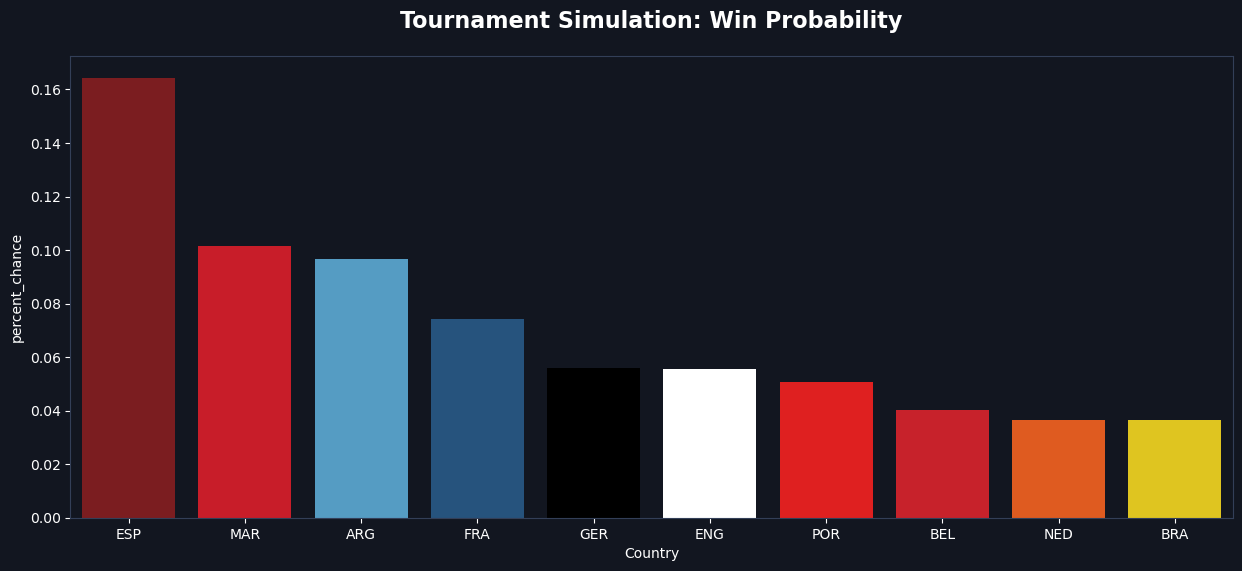

In [ ]:
country_colors = {
    'ESP': '#8B0D11', 'MAR': '#E50011', 'ARG': '#43A1D5', 'FRA': '#17548C', 
    'GER': '#000000', 'ENG': '#FFFFFF', 'POR': '#FF0000', 'BEL': '#E30613', 
    'NED': '#FF4F00', 'BRA': '#FFDC00'
}

fig = plt.figure(figsize = (15, 6), facecolor = '#121620')

ax = plt.subplot(111)
ax.set_facecolor('#121620')

sns.barplot(
    data = sim_results.sort_values(by = 'percent_chance', ascending = False).head(10),
    x = 'Country',
    y = 'percent_chance',
    hue = 'Country',
    palette = country_colors,  
    legend = False,
    ax = ax
)

ax.tick_params(colors = 'white')
ax.xaxis.label.set_color('white')
ax.yaxis.label.set_color('white')
for spine in ax.spines.values():
    spine.set_color('#333F58')

ax.set_title(
    "Tournament Simulation: Win Probability", 
    color = 'white', 
    fontsize = 16, 
    fontweight = 'bold', 
    pad = 20
)

plt.show()